In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Meghavath Sai teja_RESUME.pdf', 'archive.zip', 'crop_disease_mobilenetv2.keras', 'crop_monitoring_results.csv', 'Crop_Monitoring_Final_Report.txt', 'Crop_Disease_Detection_Project.zip', 'plant disease detection.gprj', 'plant disease detection', 'PlantDoc.v2-resize-100x100.yolov8.zip', 'PlantDoc-Object-Detection-Dataset-master.zip']


In [ ]:
zip_path = "/content/drive/MyDrive/PlantDoc-Object-Detection-Dataset-master.zip"

import os

print("Dataset found:", os.path.exists(zip_path))

Dataset found: True


In [ ]:
import zipfile
import os

extract_path = "/content/PlantDoc"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully")

✅ Dataset extracted successfully


In [ ]:
import os

for root, dirs, files in os.walk("/content/PlantDoc"):
    level = root.replace("/content/PlantDoc", "").count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

        for file in files[:10]:
            print("  " * (level + 1) + file)

PlantDoc/
  PlantDoc-Object-Detection-Dataset-master/
    README.md
    LICENSE.txt
    test_labels.csv
    train_labels.csv
    TEST/
      irish-blight-symptoms-on-potato-leaves-atmf8b.jpg
      9511.img.xml
      main-qimg-d9c2a93f60568485c989670d9bbf703b.xml
      apple-leaf-closeup-37636177.jpg
      2013Corn_GrayLeafSpot_0815_0003.JPG.jpg
      earlyblightpotato.xml
      Black%20rot%20on%20foliage.xml
      early_blight1-150x150.xml
      tmv-tomato-9.jpg
      P1130286.jpg
    TRAIN/
      stock-photo-red-apple-with-leaf-124592107.jpg
      late-blight-fungicides.xml
      stock-photo-apple-leaf-set-isolated-on-white-background-300957002.xml
      1355.51grayleafspot.jpg
      5HttOvj.jpg
      zT5la.jpg
      potato-early-blight-alternaria-alternata-discreet-lesions-on-a-potato-BY651F.xml
      lateblight1.JPG.xml
      powderymildew-on-squash.xml
      Kelley%20Gray%20leaf%20spot.jpg


In [ ]:
import os

dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"

train_path = os.path.join(dataset_root, "TRAIN")
test_path = os.path.join(dataset_root, "TEST")

train_images = []
train_xml = []

for file in os.listdir(train_path):
    if file.lower().endswith((".jpg", ".jpeg", ".png", ".JPG", ".JPEG")):
        train_images.append(file)
    elif file.lower().endswith(".xml"):
        train_xml.append(file)

test_images = []
test_xml = []

for file in os.listdir(test_path):
    if file.lower().endswith((".jpg", ".jpeg", ".png", ".JPG", ".JPEG")):
        test_images.append(file)
    elif file.lower().endswith(".xml"):
        test_xml.append(file)

print("===== PlantDoc Dataset =====")
print("Training images     :", len(train_images))
print("Training annotations:", len(train_xml))
print("Testing images      :", len(test_images))
print("Testing annotations :", len(test_xml))

===== PlantDoc Dataset =====
Training images     : 2357
Training annotations: 2356
Testing images      : 239
Testing annotations : 237


In [ ]:
import os
import xml.etree.ElementTree as ET
from collections import Counter

dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"

class_counts = Counter()

for folder in ["TRAIN", "TEST"]:
    folder_path = os.path.join(dataset_root, folder)

    for file in os.listdir(folder_path):
        if file.lower().endswith(".xml"):
            xml_path = os.path.join(folder_path, file)

            try:
                tree = ET.parse(xml_path)
                root = tree.getroot()

                for obj in root.findall("object"):
                    name = obj.find("name").text.strip()
                    class_counts[name] += 1

            except Exception as e:
                pass

print("Number of classes:", len(class_counts))
print("\nClasses and annotation counts:")

for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count}")

Number of classes: 29

Classes and annotation counts:
Apple Scab Leaf: 171
Apple leaf: 247
Apple rust leaf: 179
Bell_pepper leaf: 323
Bell_pepper leaf spot: 264
Blueberry leaf: 849
Cherry leaf: 240
Corn Gray leaf spot: 79
Corn leaf blight: 372
Corn rust leaf: 127
Peach leaf: 620
Potato leaf: 11
Potato leaf early blight: 333
Potato leaf late blight: 250
Raspberry leaf: 556
Soyabean leaf: 266
Squash Powdery mildew leaf: 257
Strawberry leaf: 492
Tomato Early blight leaf: 214
Tomato Septoria leaf spot: 436
Tomato leaf: 396
Tomato leaf bacterial spot: 280
Tomato leaf late blight: 221
Tomato leaf mosaic virus: 261
Tomato leaf yellow virus: 829
Tomato mold leaf: 293
Tomato two spotted spider mites leaf: 2
grape leaf: 220
grape leaf black rot: 133


In [ ]:
import os
import xml.etree.ElementTree as ET

train_path = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master/TRAIN"

xml_file = next(
    f for f in os.listdir(train_path)
    if f.lower().endswith(".xml")
)

xml_path = os.path.join(train_path, xml_file)

print("XML file:", xml_file)
print("\nAnnotation content:\n")

tree = ET.parse(xml_path)
root = tree.getroot()

for obj in root.findall("object"):
    name = obj.find("name").text.strip()
    bbox = obj.find("bndbox")

    xmin = bbox.find("xmin").text
    ymin = bbox.find("ymin").text
    xmax = bbox.find("xmax").text
    ymax = bbox.find("ymax").text

    print("Class :", name)
    print("Box   :", xmin, ymin, xmax, ymax)
    print()

XML file: late-blight-fungicides.xml

Annotation content:

Class : Tomato leaf late blight
Box   : 146 7 2056 763

Class : Tomato leaf late blight
Box   : 129 644 1822 1484



In [ ]:
import os

# Main project directory
project_dir = "/content/Crop_Disease_Project"

# MobileNetV2 directories
mobilenet_dir = os.path.join(project_dir, "MobileNetV2")

# YOLOv8 directories
yolo_dir = os.path.join(project_dir, "YOLOv8")

folders = [
    mobilenet_dir,
    os.path.join(mobilenet_dir, "train"),
    os.path.join(mobilenet_dir, "val"),
    os.path.join(mobilenet_dir, "test"),

    yolo_dir,
    os.path.join(yolo_dir, "images", "train"),
    os.path.join(yolo_dir, "images", "val"),
    os.path.join(yolo_dir, "images", "test"),
    os.path.join(yolo_dir, "labels", "train"),
    os.path.join(yolo_dir, "labels", "val"),
    os.path.join(yolo_dir, "labels", "test"),
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Project folders created successfully")

✅ Project folders created successfully


In [ ]:
classes = [
    "Apple Scab Leaf",
    "Apple leaf",
    "Apple rust leaf",
    "Bell_pepper leaf",
    "Bell_pepper leaf spot",
    "Blueberry leaf",
    "Cherry leaf",
    "Corn Gray leaf spot",
    "Corn leaf blight",
    "Corn rust leaf",
    "Peach leaf",
    "Potato leaf",
    "Potato leaf early blight",
    "Potato leaf late blight",
    "Raspberry leaf",
    "Soyabean leaf",
    "Squash Powdery mildew leaf",
    "Strawberry leaf",
    "Tomato Early blight leaf",
    "Tomato Septoria leaf spot",
    "Tomato leaf",
    "Tomato leaf bacterial spot",
    "Tomato leaf late blight",
    "Tomato leaf mosaic virus",
    "Tomato leaf yellow virus",
    "Tomato mold leaf",
    "Tomato two spotted spider mites leaf",
    "grape leaf",
    "grape leaf black rot"
]

class_to_id = {name: i for i, name in enumerate(classes)}
id_to_class = {i: name for i, name in enumerate(classes)}

print("Number of classes:", len(classes))
print()

for i, name in enumerate(classes):
    print(f"{i:2d} → {name}")

Number of classes: 29

 0 → Apple Scab Leaf
 1 → Apple leaf
 2 → Apple rust leaf
 3 → Bell_pepper leaf
 4 → Bell_pepper leaf spot
 5 → Blueberry leaf
 6 → Cherry leaf
 7 → Corn Gray leaf spot
 8 → Corn leaf blight
 9 → Corn rust leaf
10 → Peach leaf
11 → Potato leaf
12 → Potato leaf early blight
13 → Potato leaf late blight
14 → Raspberry leaf
15 → Soyabean leaf
16 → Squash Powdery mildew leaf
17 → Strawberry leaf
18 → Tomato Early blight leaf
19 → Tomato Septoria leaf spot
20 → Tomato leaf
21 → Tomato leaf bacterial spot
22 → Tomato leaf late blight
23 → Tomato leaf mosaic virus
24 → Tomato leaf yellow virus
25 → Tomato mold leaf
26 → Tomato two spotted spider mites leaf
27 → grape leaf
28 → grape leaf black rot


In [ ]:
import os
import shutil
import xml.etree.ElementTree as ET
from PIL import Image

dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"
yolo_dir = "/content/Crop_Disease_Project/YOLOv8"

def convert_xml_to_yolo(xml_path, image_path, label_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Get image dimensions
    with Image.open(image_path) as img:
        img_width, img_height = img.size

    yolo_annotations = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text.strip()

        if class_name not in class_to_id:
            continue

        class_id = class_to_id[class_name]

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Clamp coordinates to image boundaries
        xmin = max(0, min(xmin, img_width))
        xmax = max(0, min(xmax, img_width))
        ymin = max(0, min(ymin, img_height))
        ymax = max(0, min(ymax, img_height))

        # Skip invalid bounding boxes
        if xmax <= xmin or ymax <= ymin:
            continue

        # Convert to YOLO format
        center_x = ((xmin + xmax) / 2) / img_width
        center_y = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        yolo_annotations.append(
            f"{class_id} {center_x:.6f} {center_y:.6f} "
            f"{width:.6f} {height:.6f}"
        )

    if yolo_annotations:
        with open(label_path, "w") as f:
            f.write("\n".join(yolo_annotations))

        return True

    return False


def prepare_yolo_split(source_folder, split):
    image_output = os.path.join(yolo_dir, "images", split)
    label_output = os.path.join(yolo_dir, "labels", split)

    os.makedirs(image_output, exist_ok=True)
    os.makedirs(label_output, exist_ok=True)

    processed = 0
    skipped = 0

    for file in os.listdir(source_folder):

        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image_path = os.path.join(source_folder, file)

        # Find XML with same filename
        base_name = os.path.splitext(file)[0]
        xml_path = os.path.join(source_folder, base_name + ".xml")

        if not os.path.exists(xml_path):

            # Some files may have unusual naming/extension relationships
            skipped += 1
            continue

        label_path = os.path.join(
            label_output,
            base_name + ".txt"
        )

        try:
            success = convert_xml_to_yolo(
                xml_path,
                image_path,
                label_path
            )

            if success:
                shutil.copy2(
                    image_path,
                    os.path.join(image_output, file)
                )
                processed += 1
            else:
                skipped += 1

        except Exception as e:
            skipped += 1

    print(f"{split.upper()}:")
    print("  Processed:", processed)
    print("  Skipped  :", skipped)


# Prepare training and testing data
prepare_yolo_split(
    os.path.join(dataset_root, "TRAIN"),
    "train"
)

prepare_yolo_split(
    os.path.join(dataset_root, "TEST"),
    "test"
)

print("\n✅ YOLO conversion completed")

FileNotFoundError: [Errno 2] No such file or directory: '/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master/TRAIN'

In [ ]:
import os

for root, dirs, files in os.walk("/content/PlantDoc"):
    if "TRAIN" in dirs:
        print("TRAIN folder found at:")
        print(os.path.join(root, "TRAIN"))

    if "TEST" in dirs:
        print("TEST folder found at:")
        print(os.path.join(root, "TEST"))

In [ ]:
import os

print("Contents of /content:")
print(os.listdir("/content"))

print("\nContents of /content/PlantDoc (if it exists):")

if os.path.exists("/content/PlantDoc"):
    print(os.listdir("/content/PlantDoc"))
else:
    print("❌ /content/PlantDoc does not exist")

Contents of /content:
['.config', 'Crop_Disease_Project', 'sample_data']

Contents of /content/PlantDoc (if it exists):
❌ /content/PlantDoc does not exist


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/PlantDoc-Object-Detection-Dataset-master.zip"
extract_path = "/content/PlantDoc"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted")
print(os.listdir(extract_path))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/PlantDoc-Object-Detection-Dataset-master.zip'

In [ ]:
import os

print("Searching Google Drive for PlantDoc ZIP...\n")

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "plantdoc" in file.lower() and file.lower().endswith(".zip"):
            print(os.path.join(root, file))

Searching Google Drive for PlantDoc ZIP...



In [ ]:
import os

print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))

print("\nMy Drive contents:")
for item in os.listdir("/content/drive/MyDrive"):
    print(item)

Drive mounted: False

My Drive contents:


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive'

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))

print("\nPlantDoc ZIP files found:")

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "plantdoc" in file.lower() and file.lower().endswith(".zip"):
            print(os.path.join(root, file))

Drive mounted: True

PlantDoc ZIP files found:
/content/drive/MyDrive/PlantDoc.v2-resize-100x100.yolov8.zip
/content/drive/MyDrive/PlantDoc-Object-Detection-Dataset-master.zip


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "PlantDoc-Object-Detection-Dataset-master" in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/PlantDoc-Object-Detection-Dataset-master.zip


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/PlantDoc-Object-Detection-Dataset-master.zip"
extract_path = "/content/PlantDoc"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully")
print(os.listdir(extract_path))

✅ Dataset extracted successfully
['PlantDoc-Object-Detection-Dataset-master']


In [ ]:
import os

dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"

print("Dataset root exists:", os.path.exists(dataset_root))
print("TRAIN exists:", os.path.exists(os.path.join(dataset_root, "TRAIN")))
print("TEST exists:", os.path.exists(os.path.join(dataset_root, "TEST")))

print("\nDataset folders/files:")
for item in os.listdir(dataset_root):
    print(item)

Dataset root exists: True
TRAIN exists: True
TEST exists: True

Dataset folders/files:
TRAIN
TEST
README.md
LICENSE.txt
train_labels.csv
test_labels.csv


In [ ]:
import os
import xml.etree.ElementTree as ET
from PIL import Image

train_path = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master/TRAIN"

# Find the first XML annotation
xml_files = [
    f for f in os.listdir(train_path)
    if f.lower().endswith(".xml")
]

xml_file = xml_files[0]
xml_path = os.path.join(train_path, xml_file)

# Read XML
tree = ET.parse(xml_path)
root = tree.getroot()

print("XML file:", xml_file)

# Show filename stored inside XML
filename_tag = root.find("filename")

if filename_tag is not None:
    print("XML filename:", filename_tag.text)

# Show image size
size = root.find("size")

if size is not None:
    print("Width :", size.find("width").text)
    print("Height:", size.find("height").text)

# Show objects
print("\nObjects:")

for obj in root.findall("object"):
    name = obj.find("name").text.strip()
    bbox = obj.find("bndbox")

    print("Class:", name)
    print(
        "Bounding box:",
        bbox.find("xmin").text,
        bbox.find("ymin").text,
        bbox.find("xmax").text,
        bbox.find("ymax").text
    )

XML file: 1688.xml
XML filename: 1688.jpg
Width : 1024
Height: 768

Objects:
Class: Tomato leaf
Bounding box: 695 422 826 587
Class: Tomato leaf
Bounding box: 507 547 621 670
Class: Tomato leaf
Bounding box: 522 385 691 498
Class: Tomato leaf
Bounding box: 328 517 452 640
Class: Tomato leaf
Bounding box: 41 258 165 383
Class: Tomato leaf
Bounding box: 686 46 788 142
Class: Tomato leaf
Bounding box: 588 1 682 114
Class: Tomato leaf
Bounding box: 344 341 466 488
Class: Tomato leaf
Bounding box: 151 337 253 499
Class: Tomato leaf
Bounding box: 447 567 560 724
Class: Tomato leaf
Bounding box: 635 496 723 590
Class: Tomato leaf
Bounding box: 616 331 704 381
Class: Tomato leaf
Bounding box: 6 176 126 281
Class: Tomato leaf
Bounding box: 193 549 313 613


In [ ]:
import os
import shutil
import xml.etree.ElementTree as ET
from PIL import Image

# Paths
dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"
yolo_dir = "/content/Crop_Disease_Project/YOLOv8"

# Create YOLO folders
for split in ["train", "test"]:
    os.makedirs(os.path.join(yolo_dir, "images", split), exist_ok=True)
    os.makedirs(os.path.join(yolo_dir, "labels", split), exist_ok=True)


def find_image(folder, filename):
    """
    Find the image specified by the XML filename.
    Handles different capitalization/extensions.
    """

    # Direct match
    direct_path = os.path.join(folder, filename)

    if os.path.exists(direct_path):
        return direct_path

    # Case-insensitive search
    filename_lower = filename.lower()

    for f in os.listdir(folder):
        if f.lower() == filename_lower:
            return os.path.join(folder, f)

    return None


def convert_xml(xml_path, image_path, label_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Get image dimensions
    with Image.open(image_path) as img:
        img_width, img_height = img.size

    annotations = []

    for obj in root.findall("object"):

        class_tag = obj.find("name")

        if class_tag is None:
            continue

        class_name = class_tag.text.strip()

        # Ignore unknown classes
        if class_name not in class_to_id:
            continue

        class_id = class_to_id[class_name]

        bbox = obj.find("bndbox")

        if bbox is None:
            continue

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Keep coordinates inside image
        xmin = max(0, min(xmin, img_width))
        xmax = max(0, min(xmax, img_width))
        ymin = max(0, min(ymin, img_height))
        ymax = max(0, min(ymax, img_height))

        # Check bounding box
        if xmax <= xmin or ymax <= ymin:
            continue

        # Convert Pascal VOC → YOLO
        center_x = ((xmin + xmax) / 2) / img_width
        center_y = ((ymin + ymax) / 2) / img_height

        box_width = (xmax - xmin) / img_width
        box_height = (ymax - ymin) / img_height

        annotations.append(
            f"{class_id} "
            f"{center_x:.6f} "
            f"{center_y:.6f} "
            f"{box_width:.6f} "
            f"{box_height:.6f}"
        )

    if len(annotations) == 0:
        return False

    with open(label_path, "w") as f:
        f.write("\n".join(annotations))

    return True


def prepare_split(source_folder, split):

    image_output = os.path.join(
        yolo_dir, "images", split
    )

    label_output = os.path.join(
        yolo_dir, "labels", split
    )

    processed = 0
    skipped = 0
    errors = 0

    xml_files = [
        f for f in os.listdir(source_folder)
        if f.lower().endswith(".xml")
    ]

    for xml_file in xml_files:

        xml_path = os.path.join(
            source_folder,
            xml_file
        )

        try:

            tree = ET.parse(xml_path)
            root = tree.getroot()

            filename_tag = root.find("filename")

            if filename_tag is None:
                skipped += 1
                continue

            image_filename = filename_tag.text.strip()

            image_path = find_image(
                source_folder,
                image_filename
            )

            if image_path is None:
                skipped += 1
                continue

            # Preserve original image filename
            output_image = os.path.join(
                image_output,
                os.path.basename(image_path)
            )

            # Label filename uses image filename
            image_base = os.path.splitext(
                os.path.basename(image_path)
            )[0]

            label_path = os.path.join(
                label_output,
                image_base + ".txt"
            )

            success = convert_xml(
                xml_path,
                image_path,
                label_path
            )

            if success:

                shutil.copy2(
                    image_path,
                    output_image
                )

                processed += 1

            else:
                skipped += 1

        except Exception as e:

            errors += 1

    print(f"\n{split.upper()} DATA")
    print("-----------------------")
    print("XML files :", len(xml_files))
    print("Processed  :", processed)
    print("Skipped    :", skipped)
    print("Errors     :", errors)


# Convert training data
prepare_split(
    os.path.join(dataset_root, "TRAIN"),
    "train"
)

# Convert testing data
prepare_split(
    os.path.join(dataset_root, "TEST"),
    "test"
)

print("\n✅ YOLOv8 dataset conversion completed!")


TRAIN DATA
-----------------------
XML files : 2356
Processed  : 0
Skipped    : 13
Errors     : 2343

TEST DATA
-----------------------
XML files : 237
Processed  : 0
Skipped    : 1
Errors     : 236

✅ YOLOv8 dataset conversion completed!


In [ ]:
import os
import shutil
import random

yolo_dir = "/content/Crop_Disease_Project/YOLOv8"

train_images = os.path.join(yolo_dir, "images", "train")
train_labels = os.path.join(yolo_dir, "labels", "train")

val_images = os.path.join(yolo_dir, "images", "val")
val_labels = os.path.join(yolo_dir, "labels", "val")

os.makedirs(val_images, exist_ok=True)
os.makedirs(val_labels, exist_ok=True)

# Get training images
image_files = [
    f for f in os.listdir(train_images)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Fixed seed for reproducibility
random.seed(42)
random.shuffle(image_files)

# 20% validation
val_count = int(len(image_files) * 0.20)

val_files = image_files[:val_count]

print("Total training images:", len(image_files))
print("Validation images:", len(val_files))

moved = 0
skipped = 0

for image_file in val_files:

    image_base = os.path.splitext(image_file)[0]

    label_file = image_base + ".txt"

    image_src = os.path.join(
        train_images,
        image_file
    )

    label_src = os.path.join(
        train_labels,
        label_file
    )

    image_dst = os.path.join(
        val_images,
        image_file
    )

    label_dst = os.path.join(
        val_labels,
        label_file
    )

    # Only move if both image and label exist
    if os.path.exists(image_src) and os.path.exists(label_src):

        shutil.move(image_src, image_dst)
        shutil.move(label_src, label_dst)

        moved += 1

    else:
        skipped += 1

print("\n✅ Validation split created")
print("Moved to validation:", moved)
print("Skipped:", skipped)

print("\nRemaining training images:",
      len(os.listdir(train_images)))

print("Validation images:",
      len(os.listdir(val_images)))

Total training images: 0
Validation images: 0

✅ Validation split created
Moved to validation: 0
Skipped: 0

Remaining training images: 0
Validation images: 0


In [ ]:
import os

yolo_dir = "/content/Crop_Disease_Project/YOLOv8"

for folder in [
    "images/train",
    "images/test",
    "images/val",
    "labels/train",
    "labels/test",
    "labels/val"
]:
    path = os.path.join(yolo_dir, folder)

    print(f"\n{folder}")
    print("Exists:", os.path.exists(path))

    if os.path.exists(path):
        files = os.listdir(path)
        print("Files:", len(files))
        print("Sample:", files[:5])


images/train
Exists: True
Files: 0
Sample: []

images/test
Exists: True
Files: 0
Sample: []

images/val
Exists: True
Files: 0
Sample: []

labels/train
Exists: True
Files: 0
Sample: []

labels/test
Exists: True
Files: 0
Sample: []

labels/val
Exists: True
Files: 0
Sample: []


In [ ]:
import os
import xml.etree.ElementTree as ET

dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"
train_path = os.path.join(dataset_root, "TRAIN")

# Pick one XML file
xml_file = next(
    f for f in os.listdir(train_path)
    if f.lower().endswith(".xml")
)

xml_path = os.path.join(train_path, xml_file)

tree = ET.parse(xml_path)
root = tree.getroot()

xml_filename = root.find("filename").text.strip()

print("XML file:")
print(xml_file)

print("\nImage referenced inside XML:")
print(xml_filename)

print("\nDoes exact image exist?")
print(
    os.path.exists(
        os.path.join(train_path, xml_filename)
    )
)

print("\nFiles beginning with the same name:")

base = os.path.splitext(xml_file)[0].lower()

matches = [
    f for f in os.listdir(train_path)
    if f.lower().startswith(base)
]

for f in matches[:20]:
    print(f)

XML file:
1688.xml

Image referenced inside XML:
1688.jpg

Does exact image exist?
True

Files beginning with the same name:
1688.xml
1688.jpg


In [ ]:
import os
import shutil

yolo_dir = "/content/Crop_Disease_Project/YOLOv8"

# Remove existing YOLO dataset
if os.path.exists(yolo_dir):
    shutil.rmtree(yolo_dir)

# Recreate folders
for folder in [
    "images/train",
    "images/val",
    "images/test",
    "labels/train",
    "labels/val",
    "labels/test"
]:
    os.makedirs(os.path.join(yolo_dir, folder), exist_ok=True)

print("✅ YOLO folders reset successfully")

✅ YOLO folders reset successfully


In [ ]:
import os
import shutil
import xml.etree.ElementTree as ET
from PIL import Image

dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"
yolo_dir = "/content/Crop_Disease_Project/YOLOv8"


def find_image(folder, filename):
    """Find image regardless of filename case."""

    # Exact match
    path = os.path.join(folder, filename)

    if os.path.isfile(path):
        return path

    # Case-insensitive match
    filename_lower = filename.lower()

    for f in os.listdir(folder):
        if f.lower() == filename_lower:
            return os.path.join(folder, f)

    return None


def convert_xml_to_yolo(xml_path, image_path, label_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Get actual image dimensions
    with Image.open(image_path) as img:
        img_width, img_height = img.size

    annotations = []

    for obj in root.findall("object"):

        name = obj.find("name")

        if name is None:
            continue

        class_name = name.text.strip()

        if class_name not in class_to_id:
            continue

        class_id = class_to_id[class_name]

        bbox = obj.find("bndbox")

        if bbox is None:
            continue

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Correct invalid/out-of-range coordinates
        xmin = max(0, min(xmin, img_width))
        xmax = max(0, min(xmax, img_width))
        ymin = max(0, min(ymin, img_height))
        ymax = max(0, min(ymax, img_height))

        if xmax <= xmin or ymax <= ymin:
            continue

        # Pascal VOC → YOLO
        center_x = ((xmin + xmax) / 2) / img_width
        center_y = ((ymin + ymax) / 2) / img_height

        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        annotations.append(
            f"{class_id} "
            f"{center_x:.6f} "
            f"{center_y:.6f} "
            f"{width:.6f} "
            f"{height:.6f}"
        )

    if not annotations:
        return False

    with open(label_path, "w") as f:
        f.write("\n".join(annotations))

    return True


def convert_split(source_folder, split):

    image_output = os.path.join(
        yolo_dir, "images", split
    )

    label_output = os.path.join(
        yolo_dir, "labels", split
    )

    xml_files = [
        f for f in os.listdir(source_folder)
        if f.lower().endswith(".xml")
    ]

    processed = 0
    missing_images = 0
    invalid_annotations = 0
    errors = 0

    for xml_file in xml_files:

        xml_path = os.path.join(
            source_folder,
            xml_file
        )

        try:

            tree = ET.parse(xml_path)
            root = tree.getroot()

            filename_tag = root.find("filename")

            if filename_tag is None:
                missing_images += 1
                continue

            image_filename = filename_tag.text.strip()

            image_path = find_image(
                source_folder,
                image_filename
            )

            if image_path is None:
                missing_images += 1
                continue

            image_name = os.path.basename(image_path)
            image_base = os.path.splitext(image_name)[0]

            label_path = os.path.join(
                label_output,
                image_base + ".txt"
            )

            success = convert_xml_to_yolo(
                xml_path,
                image_path,
                label_path
            )

            if success:

                shutil.copy2(
                    image_path,
                    os.path.join(
                        image_output,
                        image_name
                    )
                )

                processed += 1

            else:
                invalid_annotations += 1

        except Exception as e:
            errors += 1

    print(f"\n===== {split.upper()} =====")
    print("XML annotations :", len(xml_files))
    print("Processed        :", processed)
    print("Missing images   :", missing_images)
    print("Invalid labels   :", invalid_annotations)
    print("Errors           :", errors)


# Convert TRAIN
convert_split(
    os.path.join(dataset_root, "TRAIN"),
    "train"
)

# Convert TEST
convert_split(
    os.path.join(dataset_root, "TEST"),
    "test"
)

print("\n✅ XML → YOLO conversion completed")


===== TRAIN =====
XML annotations : 2356
Processed        : 0
Missing images   : 3
Invalid labels   : 10
Errors           : 2343

===== TEST =====
XML annotations : 237
Processed        : 0
Missing images   : 0
Invalid labels   : 1
Errors           : 236

✅ XML → YOLO conversion completed


In [ ]:
import os
import xml.etree.ElementTree as ET
from PIL import Image

dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"
train_path = os.path.join(dataset_root, "TRAIN")

# Test the exact file we already know exists
xml_file = "1688.xml"
xml_path = os.path.join(train_path, xml_file)

try:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    image_filename = root.find("filename").text.strip()
    image_path = os.path.join(train_path, image_filename)

    print("XML:", xml_path)
    print("Image:", image_path)
    print("Image exists:", os.path.exists(image_path))

    with Image.open(image_path) as img:
        print("Image size:", img.size)
        print("Image format:", img.format)

    print("\nObjects:")
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        bbox = obj.find("bndbox")

        print(
            name,
            [
                bbox.find("xmin").text,
                bbox.find("ymin").text,
                bbox.find("xmax").text,
                bbox.find("ymax").text
            ]
        )

    print("\n✅ This annotation can be read successfully.")

except Exception as e:
    print("❌ ERROR:")
    print(type(e).__name__, ":", str(e))

XML: /content/PlantDoc/PlantDoc-Object-Detection-Dataset-master/TRAIN/1688.xml
Image: /content/PlantDoc/PlantDoc-Object-Detection-Dataset-master/TRAIN/1688.jpg
Image exists: True
Image size: (1024, 768)
Image format: JPEG

Objects:
Tomato leaf ['695', '422', '826', '587']
Tomato leaf ['507', '547', '621', '670']
Tomato leaf ['522', '385', '691', '498']
Tomato leaf ['328', '517', '452', '640']
Tomato leaf ['41', '258', '165', '383']
Tomato leaf ['686', '46', '788', '142']
Tomato leaf ['588', '1', '682', '114']
Tomato leaf ['344', '341', '466', '488']
Tomato leaf ['151', '337', '253', '499']
Tomato leaf ['447', '567', '560', '724']
Tomato leaf ['635', '496', '723', '590']
Tomato leaf ['616', '331', '704', '381']
Tomato leaf ['6', '176', '126', '281']
Tomato leaf ['193', '549', '313', '613']

✅ This annotation can be read successfully.


In [ ]:
import os
import xml.etree.ElementTree as ET
from PIL import Image

dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"
train_path = os.path.join(dataset_root, "TRAIN")

for xml_file in os.listdir(train_path):

    if not xml_file.lower().endswith(".xml"):
        continue

    xml_path = os.path.join(train_path, xml_file)

    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        filename_tag = root.find("filename")

        if filename_tag is None:
            continue

        image_filename = filename_tag.text.strip()

        # Case-insensitive image search
        image_path = None

        for f in os.listdir(train_path):
            if f.lower() == image_filename.lower():
                image_path = os.path.join(train_path, f)
                break

        if image_path is None:
            continue

        # Try opening image
        with Image.open(image_path) as img:
            width, height = img.size

        # Try reading every object
        for obj in root.findall("object"):

            name = obj.find("name")

            if name is None:
                raise ValueError("Missing class name")

            class_name = name.text.strip()

            if class_name not in class_to_id:
                raise ValueError(
                    f"Unknown class: {class_name}"
                )

            bbox = obj.find("bndbox")

            if bbox is None:
                raise ValueError("Missing bounding box")

            for coord in ["xmin", "ymin", "xmax", "ymax"]:
                if bbox.find(coord) is None:
                    raise ValueError(
                        f"Missing coordinate: {coord}"
                    )

        print("First valid file:", xml_file)
        print("Image:", image_filename)
        print("Size:", width, "x", height)
        print("Status: OK")

        break

    except Exception as e:

        print("❌ FIRST ERROR FOUND")
        print("XML:", xml_file)
        print("Error type:", type(e).__name__)
        print("Error:", str(e))
        break

❌ FIRST ERROR FOUND
XML: 1688.xml
Error type: NameError
Error: name 'class_to_id' is not defined


In [ ]:
classes = [
    "Apple Scab Leaf",
    "Apple leaf",
    "Apple rust leaf",
    "Bell_pepper leaf",
    "Bell_pepper leaf spot",
    "Blueberry leaf",
    "Cherry leaf",
    "Corn Gray leaf spot",
    "Corn leaf blight",
    "Corn rust leaf",
    "Peach leaf",
    "Potato leaf",
    "Potato leaf early blight",
    "Potato leaf late blight",
    "Raspberry leaf",
    "Soyabean leaf",
    "Squash Powdery mildew leaf",
    "Strawberry leaf",
    "Tomato Early blight leaf",
    "Tomato Septoria leaf spot",
    "Tomato leaf",
    "Tomato leaf bacterial spot",
    "Tomato leaf late blight",
    "Tomato leaf mosaic virus",
    "Tomato leaf yellow virus",
    "Tomato mold leaf",
    "Tomato two spotted spider mites leaf",
    "grape leaf",
    "grape leaf black rot"
]

class_to_id = {
    name: i for i, name in enumerate(classes)
}

id_to_class = {
    i: name for i, name in enumerate(classes)
}

print("Number of classes:", len(class_to_id))
print("Tomato leaf class ID:", class_to_id["Tomato leaf"])

Number of classes: 29
Tomato leaf class ID: 20


In [ ]:
import os
import xml.etree.ElementTree as ET
from PIL import Image

dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"
train_path = os.path.join(dataset_root, "TRAIN")

xml_file = "1688.xml"
xml_path = os.path.join(train_path, xml_file)

try:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    image_filename = root.find("filename").text.strip()

    # Find image case-insensitively
    image_path = None

    for f in os.listdir(train_path):
        if f.lower() == image_filename.lower():
            image_path = os.path.join(train_path, f)
            break

    print("XML:", xml_file)
    print("Image:", image_filename)
    print("Image exists:", image_path is not None)

    with Image.open(image_path) as img:
        img_width, img_height = img.size

    print("Image size:", img_width, "x", img_height)

    object_count = 0

    for obj in root.findall("object"):

        class_name = obj.find("name").text.strip()
        class_id = class_to_id[class_name]

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # YOLO conversion
        center_x = ((xmin + xmax) / 2) / img_width
        center_y = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        print(
            f"{class_id} "
            f"{center_x:.6f} "
            f"{center_y:.6f} "
            f"{width:.6f} "
            f"{height:.6f}"
        )

        object_count += 1

    print("\nObjects converted:", object_count)
    print("✅ Annotation conversion test successful!")

except Exception as e:
    print("❌ ERROR:", type(e).__name__, str(e))

XML: 1688.xml
Image: 1688.jpg
Image exists: True
Image size: 1024 x 768
20 0.742676 0.656901 0.127930 0.214844
20 0.550781 0.792318 0.111328 0.160156
20 0.592285 0.574870 0.165039 0.147135
20 0.380859 0.753255 0.121094 0.160156
20 0.100586 0.417318 0.121094 0.162760
20 0.719727 0.122396 0.099609 0.125000
20 0.620117 0.074870 0.091797 0.147135
20 0.395508 0.539714 0.119141 0.191406
20 0.197266 0.544271 0.099609 0.210938
20 0.491699 0.840495 0.110352 0.204427
20 0.663086 0.707031 0.085938 0.122396
20 0.644531 0.463542 0.085938 0.065104
20 0.064453 0.297526 0.117188 0.136719
20 0.247070 0.756510 0.117188 0.083333

Objects converted: 14
✅ Annotation conversion test successful!


In [ ]:
import os
import shutil
import xml.etree.ElementTree as ET
from PIL import Image

# ============================================================
# 1. PATHS
# ============================================================

dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"
yolo_dir = "/content/Crop_Disease_Project/YOLOv8"

# ============================================================
# 2. CLASS MAPPING
# ============================================================

classes = [
    "Apple Scab Leaf",
    "Apple leaf",
    "Apple rust leaf",
    "Bell_pepper leaf",
    "Bell_pepper leaf spot",
    "Blueberry leaf",
    "Cherry leaf",
    "Corn Gray leaf spot",
    "Corn leaf blight",
    "Corn rust leaf",
    "Peach leaf",
    "Potato leaf",
    "Potato leaf early blight",
    "Potato leaf late blight",
    "Raspberry leaf",
    "Soyabean leaf",
    "Squash Powdery mildew leaf",
    "Strawberry leaf",
    "Tomato Early blight leaf",
    "Tomato Septoria leaf spot",
    "Tomato leaf",
    "Tomato leaf bacterial spot",
    "Tomato leaf late blight",
    "Tomato leaf mosaic virus",
    "Tomato leaf yellow virus",
    "Tomato mold leaf",
    "Tomato two spotted spider mites leaf",
    "grape leaf",
    "grape leaf black rot"
]

class_to_id = {
    name: i for i, name in enumerate(classes)
}

# ============================================================
# 3. RESET YOLO DATASET
# ============================================================

if os.path.exists(yolo_dir):
    shutil.rmtree(yolo_dir)

for folder in [
    "images/train",
    "images/val",
    "images/test",
    "labels/train",
    "labels/val",
    "labels/test"
]:
    os.makedirs(
        os.path.join(yolo_dir, folder),
        exist_ok=True
    )

# ============================================================
# 4. FIND IMAGE
# ============================================================

def find_image(folder, filename):

    # Exact path
    direct = os.path.join(folder, filename)

    if os.path.isfile(direct):
        return direct

    # Case-insensitive search
    target = filename.lower()

    for f in os.listdir(folder):

        if f.lower() == target:
            return os.path.join(folder, f)

    return None


# ============================================================
# 5. CONVERT ONE XML
# ============================================================

def convert_xml(xml_path, image_path, label_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Read image size
    with Image.open(image_path) as img:
        img_width, img_height = img.size

    yolo_lines = []

    for obj in root.findall("object"):

        name_tag = obj.find("name")

        if name_tag is None:
            continue

        class_name = name_tag.text.strip()

        if class_name not in class_to_id:
            continue

        class_id = class_to_id[class_name]

        bbox = obj.find("bndbox")

        if bbox is None:
            continue

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Keep bounding boxes inside image
        xmin = max(0, min(xmin, img_width))
        xmax = max(0, min(xmax, img_width))

        ymin = max(0, min(ymin, img_height))
        ymax = max(0, min(ymax, img_height))

        # Invalid box
        if xmax <= xmin or ymax <= ymin:
            continue

        # Pascal VOC → YOLO
        center_x = ((xmin + xmax) / 2) / img_width
        center_y = ((ymin + ymax) / 2) / img_height

        box_width = (xmax - xmin) / img_width
        box_height = (ymax - ymin) / img_height

        yolo_lines.append(
            f"{class_id} "
            f"{center_x:.6f} "
            f"{center_y:.6f} "
            f"{box_width:.6f} "
            f"{box_height:.6f}"
        )

    if not yolo_lines:
        return False

    with open(label_path, "w") as f:
        f.write("\n".join(yolo_lines))

    return True


# ============================================================
# 6. PROCESS SPLIT
# ============================================================

def process_split(source_folder, split):

    image_output = os.path.join(
        yolo_dir,
        "images",
        split
    )

    label_output = os.path.join(
        yolo_dir,
        "labels",
        split
    )

    xml_files = [
        f for f in os.listdir(source_folder)
        if f.lower().endswith(".xml")
    ]

    processed = 0
    missing_images = 0
    invalid = 0
    errors = 0

    for index, xml_file in enumerate(xml_files):

        xml_path = os.path.join(
            source_folder,
            xml_file
        )

        try:

            tree = ET.parse(xml_path)
            root = tree.getroot()

            filename_tag = root.find("filename")

            if filename_tag is None:
                missing_images += 1
                continue

            image_filename = filename_tag.text.strip()

            image_path = find_image(
                source_folder,
                image_filename
            )

            if image_path is None:
                missing_images += 1
                continue

            image_name = os.path.basename(image_path)
            image_base = os.path.splitext(image_name)[0]

            label_path = os.path.join(
                label_output,
                image_base + ".txt"
            )

            success = convert_xml(
                xml_path,
                image_path,
                label_path
            )

            if success:

                shutil.copy2(
                    image_path,
                    os.path.join(
                        image_output,
                        image_name
                    )
                )

                processed += 1

            else:
                invalid += 1

        except Exception as e:

            errors += 1

            # Print first few errors only
            if errors <= 5:
                print(
                    "\nERROR:",
                    xml_file,
                    type(e).__name__,
                    str(e)
                )

        # Progress
        if (index + 1) % 500 == 0:
            print(
                f"{split.upper()}: "
                f"{index + 1}/{len(xml_files)} processed"
            )

    print("\n==============================")
    print(split.upper())
    print("==============================")
    print("XML files       :", len(xml_files))
    print("Processed       :", processed)
    print("Missing images  :", missing_images)
    print("Invalid labels  :", invalid)
    print("Errors          :", errors)


# ============================================================
# 7. RUN CONVERSION
# ============================================================

process_split(
    os.path.join(dataset_root, "TRAIN"),
    "train"
)

process_split(
    os.path.join(dataset_root, "TEST"),
    "test"
)

print("\n✅ COMPLETE YOLO CONVERSION FINISHED")

TRAIN: 500/2356 processed
TRAIN: 1000/2356 processed
TRAIN: 1500/2356 processed
TRAIN: 2000/2356 processed

TRAIN
XML files       : 2356
Processed       : 2343
Missing images  : 3
Invalid labels  : 10
Errors          : 0

TEST
XML files       : 237
Processed       : 236
Missing images  : 0
Invalid labels  : 1
Errors          : 0

✅ COMPLETE YOLO CONVERSION FINISHED


In [ ]:
import os

yolo_dir = "/content/Crop_Disease_Project/YOLOv8"

for split in ["train", "test"]:

    image_dir = os.path.join(
        yolo_dir, "images", split
    )

    label_dir = os.path.join(
        yolo_dir, "labels", split
    )

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    labels = [
        f for f in os.listdir(label_dir)
        if f.lower().endswith(".txt")
    ]

    image_bases = {
        os.path.splitext(f)[0]
        for f in images
    }

    label_bases = {
        os.path.splitext(f)[0]
        for f in labels
    }

    missing_labels = image_bases - label_bases
    missing_images = label_bases - image_bases

    print(f"\n===== {split.upper()} =====")
    print("Images:", len(images))
    print("Labels:", len(labels))
    print("Images without labels:", len(missing_labels))
    print("Labels without images:", len(missing_images))

print("\n✅ Dataset verification completed")


===== TRAIN =====
Images: 2342
Labels: 2342
Images without labels: 0
Labels without images: 0

===== TEST =====
Images: 236
Labels: 236
Images without labels: 0
Labels without images: 0

✅ Dataset verification completed


In [ ]:
import os
import shutil
import random

yolo_dir = "/content/Crop_Disease_Project/YOLOv8"

train_image_dir = os.path.join(yolo_dir, "images", "train")
train_label_dir = os.path.join(yolo_dir, "labels", "train")

val_image_dir = os.path.join(yolo_dir, "images", "val")
val_label_dir = os.path.join(yolo_dir, "labels", "val")

os.makedirs(val_image_dir, exist_ok=True)
os.makedirs(val_label_dir, exist_ok=True)

# Get images
images = [
    f for f in os.listdir(train_image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Reproducible shuffle
random.seed(42)
random.shuffle(images)

# 20% validation
val_count = int(len(images) * 0.20)

val_images = images[:val_count]

print("Original training images:", len(images))
print("Validation images:", val_count)
print("Remaining training images:", len(images) - val_count)

moved = 0

for image_file in val_images:

    base_name = os.path.splitext(image_file)[0]

    label_file = base_name + ".txt"

    image_src = os.path.join(
        train_image_dir,
        image_file
    )

    label_src = os.path.join(
        train_label_dir,
        label_file
    )

    image_dst = os.path.join(
        val_image_dir,
        image_file
    )

    label_dst = os.path.join(
        val_label_dir,
        label_file
    )

    # Move image and corresponding label
    if os.path.exists(image_src) and os.path.exists(label_src):

        shutil.move(image_src, image_dst)
        shutil.move(label_src, label_dst)

        moved += 1

print("\n✅ Validation split completed")
print("Moved images:", moved)

print(
    "Training images remaining:",
    len([
        f for f in os.listdir(train_image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
)

print(
    "Validation images:",
    len([
        f for f in os.listdir(val_image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
)

Original training images: 2342
Validation images: 468
Remaining training images: 1874

✅ Validation split completed
Moved images: 468
Training images remaining: 1874
Validation images: 468


In [ ]:
import os
import yaml

yolo_dir = "/content/Crop_Disease_Project/YOLOv8"

classes = [
    "Apple Scab Leaf",
    "Apple leaf",
    "Apple rust leaf",
    "Bell_pepper leaf",
    "Bell_pepper leaf spot",
    "Blueberry leaf",
    "Cherry leaf",
    "Corn Gray leaf spot",
    "Corn leaf blight",
    "Corn rust leaf",
    "Peach leaf",
    "Potato leaf",
    "Potato leaf early blight",
    "Potato leaf late blight",
    "Raspberry leaf",
    "Soyabean leaf",
    "Squash Powdery mildew leaf",
    "Strawberry leaf",
    "Tomato Early blight leaf",
    "Tomato Septoria leaf spot",
    "Tomato leaf",
    "Tomato leaf bacterial spot",
    "Tomato leaf late blight",
    "Tomato leaf mosaic virus",
    "Tomato leaf yellow virus",
    "Tomato mold leaf",
    "Tomato two spotted spider mites leaf",
    "grape leaf",
    "grape leaf black rot"
]

data = {
    "path": yolo_dir,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(classes),
    "names": classes
}

yaml_path = os.path.join(yolo_dir, "data.yaml")

with open(yaml_path, "w") as f:
    yaml.dump(
        data,
        f,
        sort_keys=False,
        default_flow_style=False
    )

print("✅ data.yaml created")
print("\nLocation:")
print(yaml_path)

print("\nContents:\n")

with open(yaml_path, "r") as f:
    print(f.read())

✅ data.yaml created

Location:
/content/Crop_Disease_Project/YOLOv8/data.yaml

Contents:

path: /content/Crop_Disease_Project/YOLOv8
train: images/train
val: images/val
test: images/test
nc: 29
names:
- Apple Scab Leaf
- Apple leaf
- Apple rust leaf
- Bell_pepper leaf
- Bell_pepper leaf spot
- Blueberry leaf
- Cherry leaf
- Corn Gray leaf spot
- Corn leaf blight
- Corn rust leaf
- Peach leaf
- Potato leaf
- Potato leaf early blight
- Potato leaf late blight
- Raspberry leaf
- Soyabean leaf
- Squash Powdery mildew leaf
- Strawberry leaf
- Tomato Early blight leaf
- Tomato Septoria leaf spot
- Tomato leaf
- Tomato leaf bacterial spot
- Tomato leaf late blight
- Tomato leaf mosaic virus
- Tomato leaf yellow virus
- Tomato mold leaf
- Tomato two spotted spider mites leaf
- grape leaf
- grape leaf black rot



In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.4 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Image: Original_e-blight.JPG.rend.hgtvcom.966.725.jpeg.jpg
Label: Original_e-blight.JPG.rend.hgtvcom.966.725.jpeg.txt
Number of bounding boxes: 1


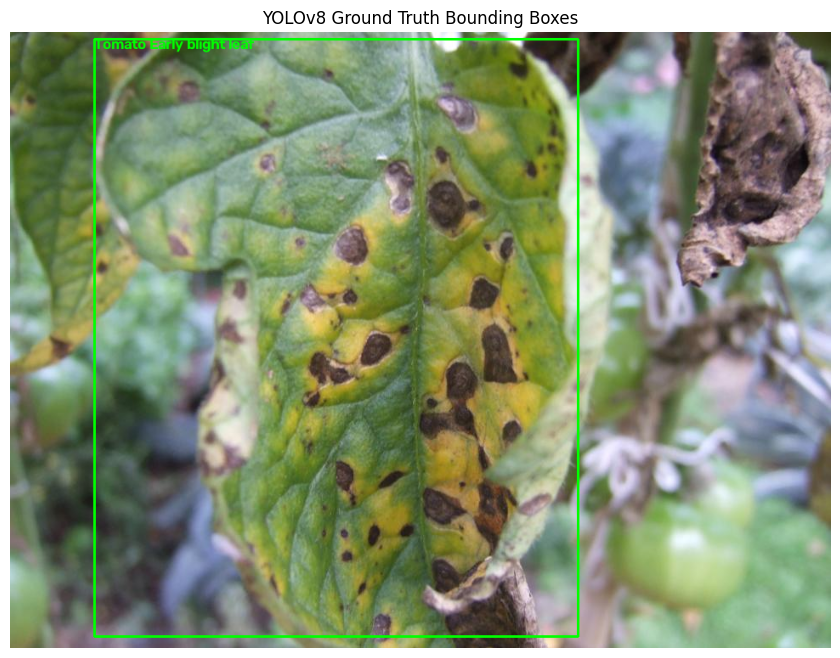

In [ ]:
from ultralytics import YOLO
from PIL import Image
import os
import random

yolo_dir = "/content/Crop_Disease_Project/YOLOv8"

image_dir = os.path.join(
    yolo_dir, "images", "train"
)

label_dir = os.path.join(
    yolo_dir, "labels", "train"
)

# Select one random training image
images = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random.seed(42)
image_file = random.choice(images)

image_path = os.path.join(image_dir, image_file)
label_path = os.path.join(
    label_dir,
    os.path.splitext(image_file)[0] + ".txt"
)

print("Image:", image_file)
print("Label:", os.path.basename(label_path))

# Load image
img = Image.open(image_path).convert("RGB")

# Read YOLO labels
with open(label_path, "r") as f:
    labels = f.readlines()

print("Number of bounding boxes:", len(labels))

# Display using Ultralytics plotting
import numpy as np
import cv2

image = np.array(img)
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

h, w = image.shape[:2]

for line in labels:

    parts = line.strip().split()

    class_id = int(parts[0])
    center_x = float(parts[1])
    center_y = float(parts[2])
    box_width = float(parts[3])
    box_height = float(parts[4])

    # Convert YOLO → pixel coordinates
    xmin = int((center_x - box_width / 2) * w)
    ymin = int((center_y - box_height / 2) * h)
    xmax = int((center_x + box_width / 2) * w)
    ymax = int((center_y + box_height / 2) * h)

    # Draw bounding box
    cv2.rectangle(
        image,
        (xmin, ymin),
        (xmax, ymax),
        (0, 255, 0),
        2
    )

    # Class name
    class_name = classes[class_id]

    cv2.putText(
        image,
        class_name,
        (xmin, max(20, ymin - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# Convert back to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("YOLOv8 Ground Truth Bounding Boxes")
plt.show()

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not available")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from ultralytics import YOLO
import os

# Paths
data_yaml = "/content/Crop_Disease_Project/YOLOv8/data.yaml"

# Load pretrained YOLOv8 Nano
model = YOLO("yolov8n.pt")

# Train
results = model.train(
    data=data_yaml,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    patience=10,
    project="/content/Crop_Disease_Project/YOLOv8/runs",
    name="plantdoc_yolov8n",
    pretrained=True,
    verbose=True
)

print("✅ YOLOv8 training completed!")

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Crop_Disease_Project/YOLOv8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plantdoc_yolov8n, nbs=64, nms=None, opset=

In [ ]:
from ultralytics import YOLO

best_model_path = (
    "/content/Crop_Disease_Project/"
    "YOLOv8/runs/plantdoc_yolov8n/weights/best.pt"
)

model = YOLO(best_model_path)

test_results = model.val(
    data="/content/Crop_Disease_Project/YOLOv8/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0
)

print("✅ Test-set evaluation completed")

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,011,303 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1359.7±871.8 MB/s, size: 135.6 KB)
val: Scanning /content/Crop_Disease_Project/YOLOv8/labels/test... 236 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 236/236 340.6it/s 0.7s
val: /content/Crop_Disease_Project/YOLOv8/images/test/02.-Rust-2017-207u24s.jpg: corrupt JPEG restored and saved
val: New cache created: /content/Crop_Disease_Project/YOLOv8/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.1it/s 7.3s
                   all        236        452      0.587        0.6      0.622       0.49
       Apple Scab Leaf         10         13      0.748      0.685      0.759      0.618
            Apple leaf          9         10      0.458        0.7      0.715      0.565
       Apple rust le

In [ ]:
import os
from collections import Counter
import xml.etree.ElementTree as ET

dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"

class_image_counts = Counter()

for split in ["TRAIN", "TEST"]:

    folder = os.path.join(dataset_root, split)

    for xml_file in os.listdir(folder):

        if not xml_file.lower().endswith(".xml"):
            continue

        xml_path = os.path.join(folder, xml_file)

        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()

            # Count each class once per image
            image_classes = set()

            for obj in root.findall("object"):

                name = obj.find("name")

                if name is not None:
                    image_classes.add(name.text.strip())

            for class_name in image_classes:
                class_image_counts[class_name] += 1

        except:
            pass

print("===== IMAGE-LEVEL CLASS DISTRIBUTION =====\n")

for class_name in classes:
    print(
        f"{class_name:<40} : "
        f"{class_image_counts[class_name]}"
    )

print("\nTotal classes:", len(classes))
print("Total class-image occurrences:", sum(class_image_counts.values()))

===== IMAGE-LEVEL CLASS DISTRIBUTION =====

Apple Scab Leaf                          : 93
Apple leaf                               : 91
Apple rust leaf                          : 89
Bell_pepper leaf                         : 61
Bell_pepper leaf spot                    : 71
Blueberry leaf                           : 117
Cherry leaf                              : 57
Corn Gray leaf spot                      : 68
Corn leaf blight                         : 193
Corn rust leaf                           : 116
Peach leaf                               : 112
Potato leaf                              : 3
Potato leaf early blight                 : 120
Potato leaf late blight                  : 106
Raspberry leaf                           : 119
Soyabean leaf                            : 65
Squash Powdery mildew leaf               : 131
Strawberry leaf                          : 96
Tomato Early blight leaf                 : 90
Tomato Septoria leaf spot                : 151
Tomato leaf                 

In [ ]:
import os
import shutil
import xml.etree.ElementTree as ET
from PIL import Image

# Paths
dataset_root = "/content/PlantDoc/PlantDoc-Object-Detection-Dataset-master"
yolo_root = "/content/Crop_Disease_Project/YOLOv8"

crop_root = "/content/Crop_Disease_Project/MobileNetV2_Dataset"

# Create folders
for split in ["train", "val", "test"]:
    for class_name in classes:
        os.makedirs(
            os.path.join(crop_root, split, class_name),
            exist_ok=True
        )

# Get YOLO train/val image filenames
train_images = set(os.listdir(os.path.join(yolo_root, "images/train")))
val_images = set(os.listdir(os.path.join(yolo_root, "images/val")))
test_images = set(os.listdir(os.path.join(yolo_root, "images/test")))

# Mapping from YOLO image name to classification split
image_split = {}

for img in train_images:
    image_split[img] = "train"

for img in val_images:
    image_split[img] = "val"

for img in test_images:
    image_split[img] = "test"

# Process original XML annotations
crop_count = {
    "train": 0,
    "val": 0,
    "test": 0
}

class_crop_count = {c: 0 for c in classes}

for source_split in ["TRAIN", "TEST"]:

    source_dir = os.path.join(dataset_root, source_split)

    for xml_file in os.listdir(source_dir):

        if not xml_file.lower().endswith(".xml"):
            continue

        xml_path = os.path.join(source_dir, xml_file)

        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()

            filename_node = root.find("filename")

            if filename_node is None:
                continue

            image_name = filename_node.text.strip()

            if image_name not in image_split:
                continue

            split = image_split[image_name]

            image_path = os.path.join(source_dir, image_name)

            if not os.path.exists(image_path):
                continue

            image = Image.open(image_path).convert("RGB")

            width, height = image.size

            object_index = 0

            for obj in root.findall("object"):

                name_node = obj.find("name")

                if name_node is None:
                    continue

                class_name = name_node.text.strip()

                if class_name not in class_to_id:
                    continue

                bbox = obj.find("bndbox")

                if bbox is None:
                    continue

                xmin = int(float(bbox.find("xmin").text))
                ymin = int(float(bbox.find("ymin").text))
                xmax = int(float(bbox.find("xmax").text))
                ymax = int(float(bbox.find("ymax").text))

                # Clamp coordinates
                xmin = max(0, min(xmin, width - 1))
                ymin = max(0, min(ymin, height - 1))
                xmax = max(0, min(xmax, width))
                ymax = max(0, min(ymax, height))

                # Skip invalid boxes
                if xmax <= xmin or ymax <= ymin:
                    continue

                # Crop object
                crop = image.crop((xmin, ymin, xmax, ymax))

                # Resize
                crop = crop.resize((224, 224))

                # Unique filename
                base_name = os.path.splitext(image_name)[0]

                crop_filename = (
                    f"{base_name}_obj{object_index}.jpg"
                )

                save_path = os.path.join(
                    crop_root,
                    split,
                    class_name,
                    crop_filename
                )

                crop.save(save_path, quality=95)

                object_index += 1
                crop_count[split] += 1
                class_crop_count[class_name] += 1

        except Exception as e:
            print("Error:", xml_file, e)

print("\n===== MOBILE NET CLASSIFICATION DATASET =====")
print("Train crops :", crop_count["train"])
print("Val crops   :", crop_count["val"])
print("Test crops  :", crop_count["test"])
print("Total crops :", sum(crop_count.values()))

print("\n===== CLASS CROP COUNTS =====")

for class_name in classes:
    print(f"{class_name:<40} : {class_crop_count[class_name]}")


===== MOBILE NET CLASSIFICATION DATASET =====
Train crops : 6828
Val crops   : 1598
Test crops  : 484
Total crops : 8910

===== CLASS CROP COUNTS =====
Apple Scab Leaf                          : 171
Apple leaf                               : 247
Apple rust leaf                          : 179
Bell_pepper leaf                         : 323
Bell_pepper leaf spot                    : 264
Blueberry leaf                           : 849
Cherry leaf                              : 240
Corn Gray leaf spot                      : 79
Corn leaf blight                         : 370
Corn rust leaf                           : 127
Peach leaf                               : 620
Potato leaf                              : 11
Potato leaf early blight                 : 327
Potato leaf late blight                  : 250
Raspberry leaf                           : 556
Soyabean leaf                            : 266
Squash Powdery mildew leaf               : 254
Strawberry leaf                          : 492
Tom

In [ ]:
import os
from PIL import Image

crop_root = "/content/Crop_Disease_Project/MobileNetV2_Dataset"

print("===== DATASET VERIFICATION =====\n")

for split in ["train", "val", "test"]:

    split_path = os.path.join(crop_root, split)

    class_folders = [
        d for d in os.listdir(split_path)
        if os.path.isdir(os.path.join(split_path, d))
    ]

    print(f"{split.upper()} classes:", len(class_folders))

    total = 0

    for class_name in classes:
        class_path = os.path.join(split_path, class_name)

        count = 0

        if os.path.exists(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

        total += count

    print(f"{split.upper()} images:", total)

# Check a sample image
sample_class = "Tomato leaf"
sample_path = os.path.join(
    crop_root,
    "train",
    sample_class
)

sample_files = [
    f for f in os.listdir(sample_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

if sample_files:
    sample_image_path = os.path.join(sample_path, sample_files[0])

    img = Image.open(sample_image_path)

    print("\n===== SAMPLE IMAGE CHECK =====")
    print("Class:", sample_class)
    print("File:", sample_files[0])
    print("Image size:", img.size)
    print("Image mode:", img.mode)

===== DATASET VERIFICATION =====

TRAIN classes: 29
TRAIN images: 6828
VAL classes: 29
VAL images: 1598
TEST classes: 29
TEST images: 476

===== SAMPLE IMAGE CHECK =====
Class: Tomato leaf
File: img_1028_obj0.jpg
Image size: (224, 224)
Image mode: RGB


In [ ]:
import tensorflow as tf
import os

crop_root = "/content/Crop_Disease_Project/MobileNetV2_Dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(crop_root, "train"),
    labels="inferred",
    label_mode="int",
    class_names=classes,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(crop_root, "val"),
    labels="inferred",
    label_mode="int",
    class_names=classes,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(crop_root, "test"),
    labels="inferred",
    label_mode="int",
    class_names=classes,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\n===== DATASET LOADED =====")
print("Number of classes:", len(train_ds.class_names))
print("Classes:", train_ds.class_names)

# Check one batch
images, labels = next(iter(train_ds))

print("\n===== BATCH CHECK =====")
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Found 6828 files belonging to 29 classes.
Found 1598 files belonging to 29 classes.
Found 476 files belonging to 29 classes.

===== DATASET LOADED =====
Number of classes: 29
Classes: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf', 'Bell_pepper leaf spot', 'Blueberry leaf', 'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf', 'Peach leaf', 'Potato leaf', 'Potato leaf early blight', 'Potato leaf late blight', 'Raspberry leaf', 'Soyabean leaf', 'Squash Powdery mildew leaf', 'Strawberry leaf', 'Tomato Early blight leaf', 'Tomato Septoria leaf spot', 'Tomato leaf', 'Tomato leaf bacterial spot', 'Tomato leaf late blight', 'Tomato leaf mosaic virus', 'Tomato leaf yellow virus', 'Tomato mold leaf', 'Tomato two spotted spider mites leaf', 'grape leaf', 'grape leaf black rot']

===== BATCH CHECK =====
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = 29

# ImageNet pretrained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained base
base_model.trainable = False

# Build classification model
inputs = layers.Input(shape=(224, 224, 3))

# MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

mobilenet_model = models.Model(
    inputs,
    outputs,
    name="PlantDoc_MobileNetV2"
)

# Compile
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("===== MODEL CREATED =====")
mobilenet_model.summary()

print("\nTotal parameters:", mobilenet_model.count_params())
print("Trainable parameters:",
      sum(tf.size(w).numpy() for w in mobilenet_model.trainable_weights))
print("Non-trainable parameters:",
      sum(tf.size(w).numpy() for w in mobilenet_model.non_trainable_weights))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
===== MODEL CREATED =====


Model: "PlantDoc_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 29)             │        37,149 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,295,133 (8.76 MB)

 Trainable params: 37,149 (145.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total parameters: 2295133
Trainable parameters: 37149
Non-trainable parameters: 2257984


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Get labels from the training dataset
train_labels = []

for _, labels in train_ds:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)

# Calculate balanced class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)

class_weights = {
    i: float(weight)
    for i, weight in enumerate(class_weights_array)
}

print("===== CLASS WEIGHTS =====\n")

for i, class_name in enumerate(classes):
    print(f"{i:2d}  {class_name:<40} : {class_weights[i]:.4f}")

print("\nMinimum weight:", min(class_weights.values()))
print("Maximum weight:", max(class_weights.values()))

===== CLASS WEIGHTS =====

 0  Apple Scab Leaf                          : 1.7837
 1  Apple leaf                               : 1.3532
 2  Apple rust leaf                          : 1.8988
 3  Bell_pepper leaf                         : 0.9418
 4  Bell_pepper leaf spot                    : 1.1542
 5  Blueberry leaf                           : 0.3828
 6  Cherry leaf                              : 1.4445
 7  Corn Gray leaf spot                      : 3.8598
 8  Corn leaf blight                         : 0.8008
 9  Corn rust leaf                           : 2.5317
10  Peach leaf                               : 0.4563
11  Potato leaf                              : 21.4044
12  Potato leaf early blight                 : 0.9161
13  Potato leaf late blight                  : 1.2392
14  Raspberry leaf                           : 0.5175
15  Soyabean leaf                            : 1.1265
16  Squash Powdery mildew leaf               : 1.1656
17  Strawberry leaf                          : 0.6295


In [ ]:
# Cap extremely large class weights
MAX_CLASS_WEIGHT = 10.0

class_weights_capped = {
    i: min(weight, MAX_CLASS_WEIGHT)
    for i, weight in class_weights.items()
}

print("===== FINAL CLASS WEIGHTS =====\n")

for i, class_name in enumerate(classes):
    print(
        f"{i:2d}  {class_name:<40} : "
        f"{class_weights_capped[i]:.4f}"
    )

print("\nOriginal maximum weight:",
      max(class_weights.values()))

print("Capped maximum weight:",
      max(class_weights_capped.values()))


# --------------------------------------------------
# Training callbacks
# --------------------------------------------------

checkpoint_path = (
    "/content/Crop_Disease_Project/"
    "MobileNetV2_best_stage1.keras"
)

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("\n===== CALLBACKS READY =====")
print("Best model will be saved to:")
print(checkpoint_path)

===== FINAL CLASS WEIGHTS =====

 0  Apple Scab Leaf                          : 1.7837
 1  Apple leaf                               : 1.3532
 2  Apple rust leaf                          : 1.8988
 3  Bell_pepper leaf                         : 0.9418
 4  Bell_pepper leaf spot                    : 1.1542
 5  Blueberry leaf                           : 0.3828
 6  Cherry leaf                              : 1.4445
 7  Corn Gray leaf spot                      : 3.8598
 8  Corn leaf blight                         : 0.8008
 9  Corn rust leaf                           : 2.5317
10  Peach leaf                               : 0.4563
11  Potato leaf                              : 10.0000
12  Potato leaf early blight                 : 0.9161
13  Potato leaf late blight                  : 1.2392
14  Raspberry leaf                           : 0.5175
15  Soyabean leaf                            : 1.1265
16  Squash Powdery mildew leaf               : 1.1656
17  Strawberry leaf                          : 0

In [ ]:
print("===== STAGE 1 TRAINING STARTED =====")
print("MobileNetV2 base: FROZEN")
print("Trainable parameters:",
      sum(tf.size(w).numpy() for w in mobilenet_model.trainable_weights))
print("Maximum epochs: 15")
print()

history_stage1 = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_capped,
    callbacks=callbacks,
    verbose=1
)

print("\n===== STAGE 1 TRAINING COMPLETE =====")

===== STAGE 1 TRAINING STARTED =====
MobileNetV2 base: FROZEN
Trainable parameters: 37149
Maximum epochs: 15

Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2108 - loss: 2.8498
Epoch 1: val_accuracy improved from None to 0.44493, saving model to /content/Crop_Disease_Project/MobileNetV2_best_stage1.keras

Epoch 1: finished saving model to /content/Crop_Disease_Project/MobileNetV2_best_stage1.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 61s 190ms/step - accuracy: 0.3270 - loss: 2.3391 - val_accuracy: 0.4449 - val_loss: 1.8341 - learning_rate: 0.0010
Epoch 2/15
212/214 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5120 - loss: 1.5096
Epoch 2: val_accuracy improved from 0.44493 to 0.46370, saving model to /content/Crop_Disease_Project/MobileNetV2_best_stage1.keras

Epoch 2: finished saving model to /content/Crop_Disease_Project/MobileNetV2_best_stage1.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.5343 - loss: 1.4587 - val_accuracy: 0.4637 - val_loss: 1.7360 - 

In [ ]:
# Load the best Stage 1 model
stage1_model = tf.keras.models.load_model(
    "/content/Crop_Disease_Project/MobileNetV2_best_stage1.keras"
)

print("===== STAGE 1 TEST EVALUATION =====")

test_loss, test_accuracy = stage1_model.evaluate(
    test_ds,
    verbose=1
)

print("\nStage 1 Test Loss     :", round(test_loss, 4))
print("Stage 1 Test Accuracy :", round(test_accuracy * 100, 2), "%")

===== STAGE 1 TEST EVALUATION =====
15/15 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5189 - loss: 1.5952

Stage 1 Test Loss     : 1.5952
Stage 1 Test Accuracy : 51.89 %


In [ ]:
# Load the best Stage 1 model
mobilenet_model = tf.keras.models.load_model(
    "/content/Crop_Disease_Project/MobileNetV2_best_stage1.keras"
)

# Get MobileNetV2 base model
base_model = mobilenet_model.get_layer("mobilenetv2_1.00_224")

# Unfreeze the base model
base_model.trainable = True

# Freeze early layers and BatchNormalization layers
# Fine-tune only the later feature-extraction layers
fine_tune_from = 100

for i, layer in enumerate(base_model.layers):

    if i < fine_tune_from:
        layer.trainable = False

    elif isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

    else:
        layer.trainable = True

# Recompile with a very small learning rate
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

trainable_params = sum(
    tf.size(w).numpy()
    for w in mobilenet_model.trainable_weights
)

non_trainable_params = sum(
    tf.size(w).numpy()
    for w in mobilenet_model.non_trainable_weights
)

print("===== FINE-TUNING MODEL READY =====")
print("MobileNetV2 layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_from)
print("Learning rate: 1e-5")
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

===== FINE-TUNING MODEL READY =====
MobileNetV2 layers: 154
Fine-tuning from layer: 100
Learning rate: 1e-5
Trainable parameters: 1876765
Non-trainable parameters: 418368


In [ ]:
# Fine-tuning callbacks
fine_tune_checkpoint = (
    "/content/Crop_Disease_Project/"
    "MobileNetV2_best_finetuned.keras"
)

fine_tune_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        fine_tune_checkpoint,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("===== FINE-TUNING STARTED =====")
print("Trainable parameters:",
      sum(tf.size(w).numpy() for w in mobilenet_model.trainable_weights))
print("Maximum epochs: 15")
print("Learning rate: 1e-5")
print()

history_finetune = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_capped,
    callbacks=fine_tune_callbacks,
    verbose=1
)

print("\n===== FINE-TUNING COMPLETE =====")

===== FINE-TUNING STARTED =====
Trainable parameters: 1876765
Maximum epochs: 15
Learning rate: 1e-5

Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7451 - loss: 0.6886
Epoch 1: val_accuracy improved from None to 0.56195, saving model to /content/Crop_Disease_Project/MobileNetV2_best_finetuned.keras

Epoch 1: finished saving model to /content/Crop_Disease_Project/MobileNetV2_best_finetuned.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 43s 129ms/step - accuracy: 0.7594 - loss: 0.6615 - val_accuracy: 0.5620 - val_loss: 1.5533 - learning_rate: 1.0000e-05
Epoch 2/15
213/214 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7907 - loss: 0.5842
Epoch 2: val_accuracy improved from 0.56195 to 0.56258, saving model to /content/Crop_Disease_Project/MobileNetV2_best_finetuned.keras

Epoch 2: finished saving model to /content/Crop_Disease_Project/MobileNetV2_best_finetuned.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.7948 - loss: 0.5710 - val_accuracy: 0.5626 - val_loss: 1

In [ ]:
# Load the best fine-tuned model
finetuned_model = tf.keras.models.load_model(
    "/content/Crop_Disease_Project/MobileNetV2_best_finetuned.keras"
)

print("===== FINAL MOBILENETV2 TEST EVALUATION =====")

test_loss_ft, test_accuracy_ft = finetuned_model.evaluate(
    test_ds,
    verbose=1
)

print("\nFinal Test Loss     :", round(test_loss_ft, 4))
print("Final Test Accuracy :", round(test_accuracy_ft * 100, 2), "%")

===== FINAL MOBILENETV2 TEST EVALUATION =====
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step - accuracy: 0.5378 - loss: 1.6256

Final Test Loss     : 1.6256
Final Test Accuracy : 53.78 %


In [ ]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("===== GENERATING PREDICTIONS =====")

# Get true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = finetuned_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Test samples:", len(y_true))

# Overall metrics
precision_macro = precision_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

precision_weighted = precision_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

print("\n===== OVERALL METRICS =====")
print(f"Accuracy          : {np.mean(y_true == y_pred) * 100:.2f}%")
print(f"Macro Precision   : {precision_macro:.4f}")
print(f"Macro Recall      : {recall_macro:.4f}")
print(f"Macro F1 Score    : {f1_macro:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall   : {recall_weighted:.4f}")
print(f"Weighted F1 Score : {f1_weighted:.4f}")

# Classification report
print("\n===== 29-CLASS CLASSIFICATION REPORT =====\n")

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=classes,
    digits=4,
    zero_division=0
)

print(report)

# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

print("Confusion matrix shape:", cm.shape)

===== GENERATING PREDICTIONS =====
Test samples: 476

===== OVERALL METRICS =====
Accuracy          : 53.78%
Macro Precision   : 0.5329
Macro Recall      : 0.5483
Macro F1 Score    : 0.5308
Weighted Precision: 0.5417
Weighted Recall   : 0.5378
Weighted F1 Score : 0.5301

===== 29-CLASS CLASSIFICATION REPORT =====

                                      precision    recall  f1-score   support

                     Apple Scab Leaf     0.5000    0.4615    0.4800        13
                          Apple leaf     0.4615    0.6000    0.5217        10
                     Apple rust leaf     0.7000    0.6364    0.6667        11
                    Bell_pepper leaf     0.4000    0.5455    0.4615        11
               Bell_pepper leaf spot     0.3000    0.3913    0.3396        23
                      Blueberry leaf     0.8000    0.9091    0.8511        22
                         Cherry leaf     0.4286    0.1579    0.2308        19
                 Corn Gray leaf spot     0.4000    0.5714  

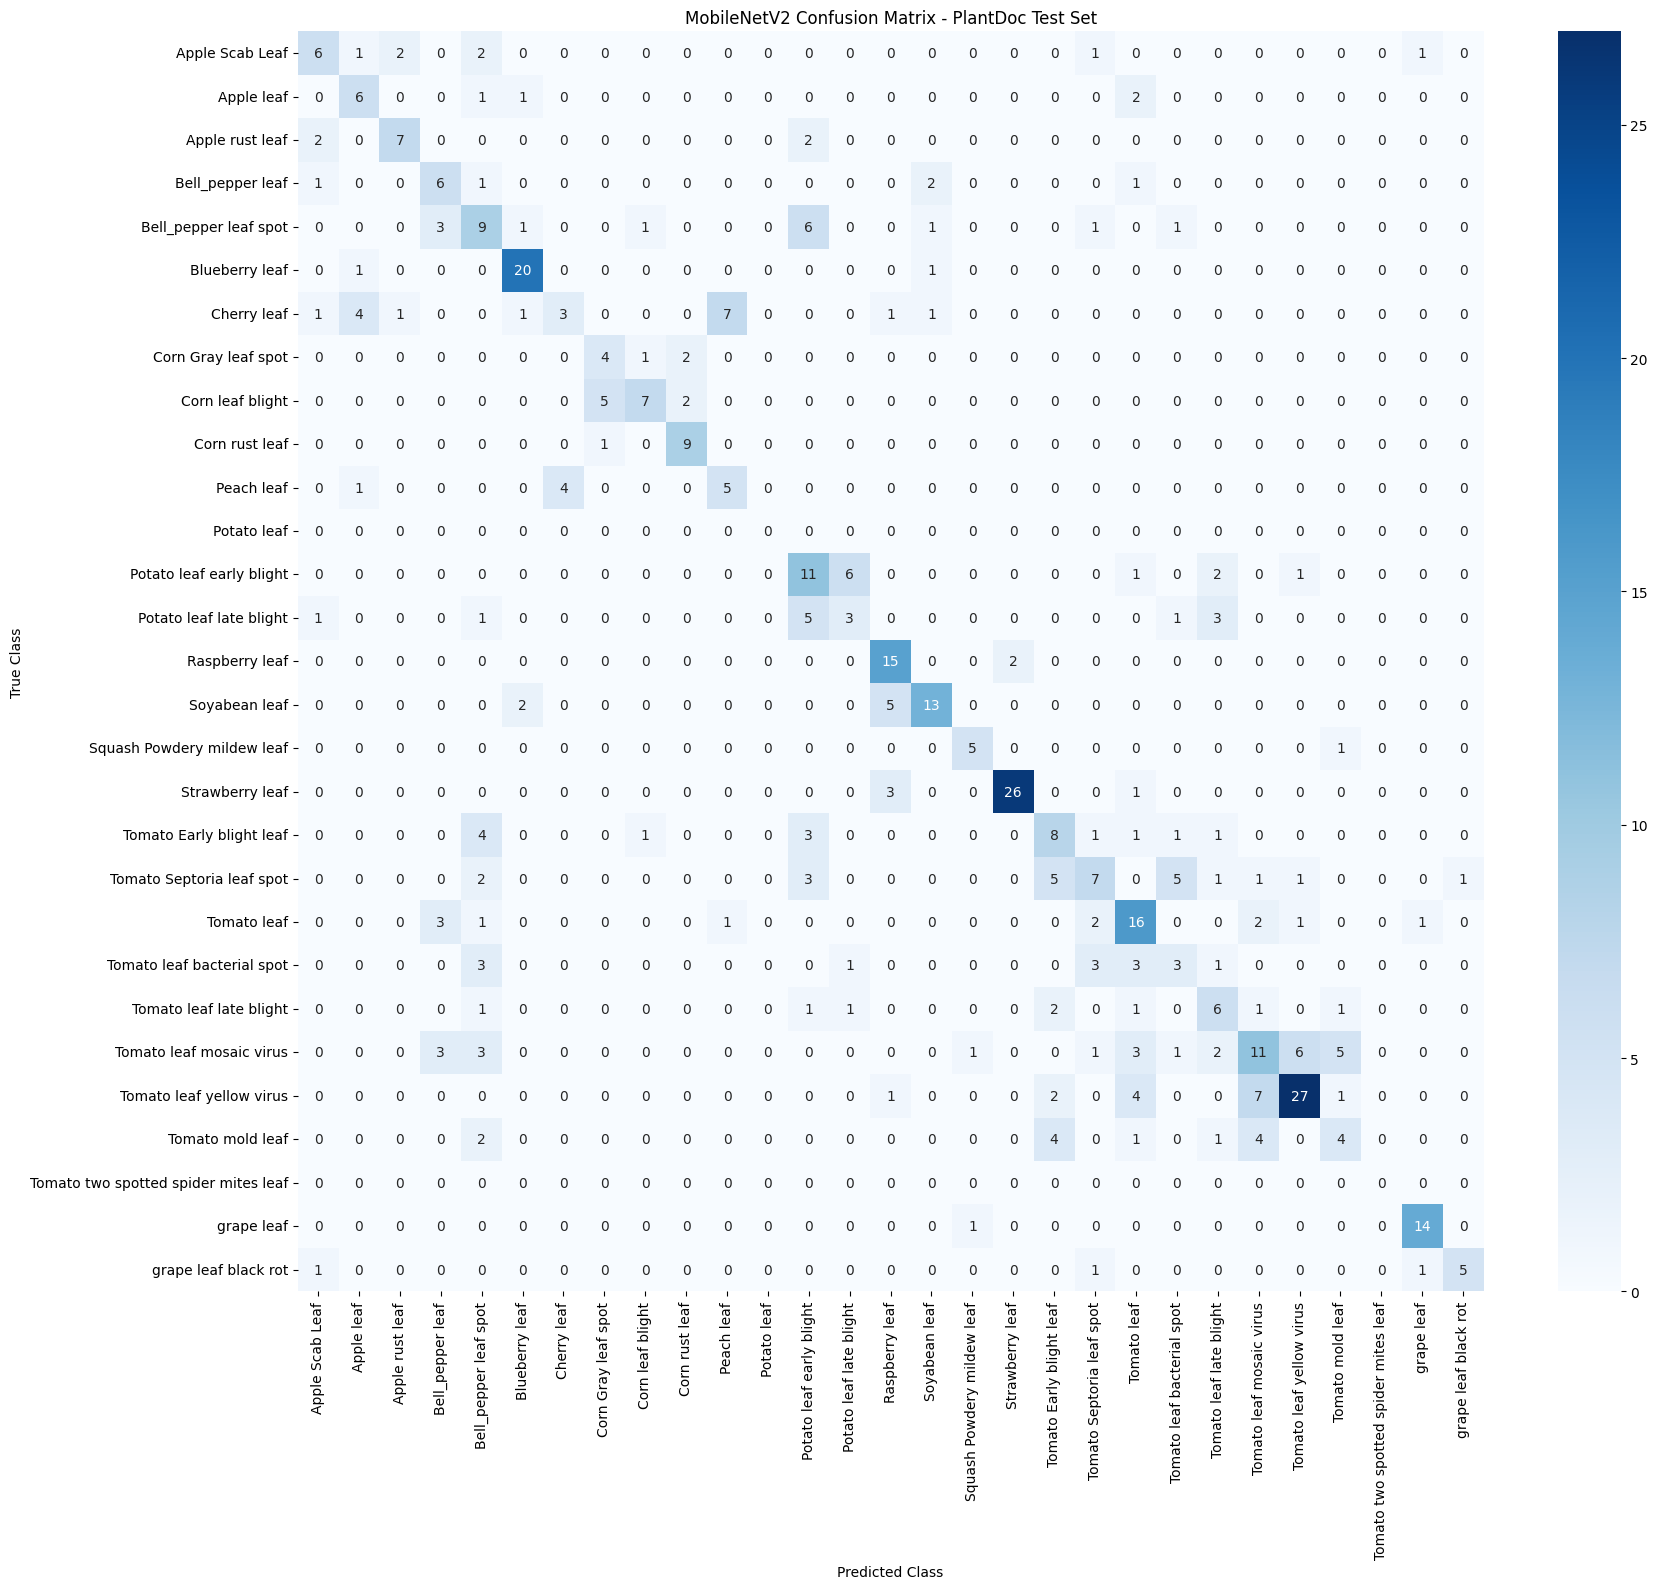

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("MobileNetV2 Confusion Matrix - PlantDoc Test Set")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [ ]:
# Find the most common misclassification pairs
confusions = []

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confusions.append(
                (cm[i, j], classes[i], classes[j])
            )

confusions = sorted(confusions, reverse=True)

print("===== TOP 15 MISCLASSIFICATIONS =====\n")

for count, true_class, predicted_class in confusions[:15]:
    print(
        f"{count:2d}  | True: {true_class}"
        f"  --> Predicted: {predicted_class}"
    )

===== TOP 15 MISCLASSIFICATIONS =====

 7  | True: Tomato leaf yellow virus  --> Predicted: Tomato leaf mosaic virus
 7  | True: Cherry leaf  --> Predicted: Peach leaf
 6  | True: Tomato leaf mosaic virus  --> Predicted: Tomato leaf yellow virus
 6  | True: Potato leaf early blight  --> Predicted: Potato leaf late blight
 6  | True: Bell_pepper leaf spot  --> Predicted: Potato leaf early blight
 5  | True: Tomato leaf mosaic virus  --> Predicted: Tomato mold leaf
 5  | True: Tomato Septoria leaf spot  --> Predicted: Tomato leaf bacterial spot
 5  | True: Tomato Septoria leaf spot  --> Predicted: Tomato Early blight leaf
 5  | True: Soyabean leaf  --> Predicted: Raspberry leaf
 5  | True: Potato leaf late blight  --> Predicted: Potato leaf early blight
 5  | True: Corn leaf blight  --> Predicted: Corn Gray leaf spot
 4  | True: Tomato mold leaf  --> Predicted: Tomato leaf mosaic virus
 4  | True: Tomato mold leaf  --> Predicted: Tomato Early blight leaf
 4  | True: Tomato leaf yellow vi

In [ ]:
# Per-class F1 score ranking

from sklearn.metrics import f1_score

class_f1 = f1_score(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    average=None,
    zero_division=0
)

class_results = []

for i, class_name in enumerate(classes):
    class_results.append((class_name, class_f1[i]))

class_results = sorted(class_results, key=lambda x: x[1], reverse=True)

print("===== PER-CLASS F1 SCORE =====\n")

for rank, (class_name, score) in enumerate(class_results, 1):
    print(f"{rank:2d}. {class_name:<40} {score:.4f}")

===== PER-CLASS F1 SCORE =====

 1. Strawberry leaf                          0.8966
 2. grape leaf                               0.8750
 3. Blueberry leaf                           0.8511
 4. Corn rust leaf                           0.7826
 5. Squash Powdery mildew leaf               0.7692
 6. Raspberry leaf                           0.7143
 7. grape leaf black rot                     0.7143
 8. Tomato leaf yellow virus                 0.6923
 9. Soyabean leaf                            0.6842
10. Apple rust leaf                          0.6667
11. Corn leaf blight                         0.5833
12. Tomato leaf                              0.5246
13. Apple leaf                               0.5217
14. Apple Scab Leaf                          0.4800
15. Corn Gray leaf spot                      0.4706
16. Bell_pepper leaf                         0.4615
17. Peach leaf                               0.4348
18. Potato leaf early blight                 0.4231
19. Tomato Early blight leaf    

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get training labels
train_labels = np.concatenate([
    labels.numpy() for _, labels in train_ds
])

# Calculate balanced class weights
raw_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)

class_weights_improved = {
    i: float(raw_weights[i])
    for i in range(NUM_CLASSES)
}

print("===== IMPROVED CLASS WEIGHTS =====\n")

for i, class_name in enumerate(classes):
    print(
        f"{class_name:<45} "
        f"{class_weights_improved[i]:.4f}"
    )

===== IMPROVED CLASS WEIGHTS =====

Apple Scab Leaf                               1.7837
Apple leaf                                    1.3532
Apple rust leaf                               1.8988
Bell_pepper leaf                              0.9418
Bell_pepper leaf spot                         1.1542
Blueberry leaf                                0.3828
Cherry leaf                                   1.4445
Corn Gray leaf spot                           3.8598
Corn leaf blight                              0.8008
Corn rust leaf                                2.5317
Peach leaf                                    0.4563
Potato leaf                                   21.4044
Potato leaf early blight                      0.9161
Potato leaf late blight                       1.2392
Raspberry leaf                                0.5175
Soyabean leaf                                 1.1265
Squash Powdery mildew leaf                    1.1656
Strawberry leaf                               0.6295
Tomato Ea

In [ ]:
# Stable class weights:
# 1. Square-root compression reduces extreme weights
# 2. Maximum weight of 5 prevents rare classes dominating training

class_weights_improved = {}

for i in range(NUM_CLASSES):
    weight = np.sqrt(raw_weights[i])
    weight = min(weight, 5.0)
    class_weights_improved[i] = float(weight)

print("===== STABLE IMPROVED CLASS WEIGHTS =====\n")

for i, class_name in enumerate(classes):
    print(
        f"{class_name:<45} "
        f"{class_weights_improved[i]:.4f}"
    )

===== STABLE IMPROVED CLASS WEIGHTS =====

Apple Scab Leaf                               1.3356
Apple leaf                                    1.1633
Apple rust leaf                               1.3780
Bell_pepper leaf                              0.9705
Bell_pepper leaf spot                         1.0743
Blueberry leaf                                0.6187
Cherry leaf                                   1.2019
Corn Gray leaf spot                           1.9646
Corn leaf blight                              0.8949
Corn rust leaf                                1.5911
Peach leaf                                    0.6755
Potato leaf                                   4.6265
Potato leaf early blight                      0.9572
Potato leaf late blight                       1.1132
Raspberry leaf                                0.7194
Soyabean leaf                                 1.0614
Squash Powdery mildew leaf                    1.0796
Strawberry leaf                               0.7934
Tom

In [ ]:
import tensorflow as tf

# Load the best MobileNetV2 model from the previous experiment
improved_model = tf.keras.models.load_model(
    "/content/Crop_Disease_Project/MobileNetV2_best_finetuned.keras"
)

print("Model loaded successfully.")
print("Total parameters:", improved_model.count_params())

Model loaded successfully.
Total parameters: 2295133


In [ ]:
# Recompile improved model

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("===== IMPROVED MODEL READY =====")
print("Optimizer      : Adam")
print("Learning rate  : 1e-5")
print("Class weights  : Stable sqrt-balanced weights")
print("Max weight     : 5.0")

===== IMPROVED MODEL READY =====
Optimizer      : Adam
Learning rate  : 1e-5
Class weights  : Stable sqrt-balanced weights
Max weight     : 5.0


In [ ]:
# Callbacks for improved training

improved_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/Crop_Disease_Project/MobileNetV2_best_improved.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

improved_earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

improved_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("Callbacks ready.")

Callbacks ready.


In [ ]:
history_improved = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_improved,
    callbacks=[
        improved_checkpoint,
        improved_earlystop,
        improved_reduce_lr
    ]
)

Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8425 - loss: 0.4424
Epoch 1: val_accuracy improved from None to 0.58073, saving model to /content/Crop_Disease_Project/MobileNetV2_best_improved.keras

Epoch 1: finished saving model to /content/Crop_Disease_Project/MobileNetV2_best_improved.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - accuracy: 0.8467 - loss: 0.4380 - val_accuracy: 0.5807 - val_loss: 1.5282 - learning_rate: 1.0000e-05
Epoch 2/15
213/214 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8584 - loss: 0.3931
Epoch 2: val_accuracy did not improve from 0.58073
214/214 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.8625 - loss: 0.3907 - val_accuracy: 0.5788 - val_loss: 1.4927 - learning_rate: 1.0000e-05
Epoch 3/15
213/214 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8756 - loss: 0.3627
Epoch 3: val_accuracy did not improve from 0.58073
214/214 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.8827 - loss: 0.3538 - val_accuracy: 0.5807 - val_loss: 1.

In [ ]:
# Load the best improved model saved during training
improved_best_model = tf.keras.models.load_model(
    "/content/Crop_Disease_Project/MobileNetV2_best_improved.keras"
)

# Evaluate on the untouched test set
improved_test_loss, improved_test_accuracy = improved_best_model.evaluate(
    test_ds,
    verbose=1
)

print("\n===== IMPROVED MODEL TEST RESULTS =====")
print(f"Test Loss     : {improved_test_loss:.4f}")
print(f"Test Accuracy : {improved_test_accuracy * 100:.2f}%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 271ms/step - accuracy: 0.5357 - loss: 1.6447

===== IMPROVED MODEL TEST RESULTS =====
Test Loss     : 1.6447
Test Accuracy : 53.57%


In [ ]:
# ============================================================
# STEP 1 — FINAL PROJECT METRICS SUMMARY
# ============================================================

import numpy as np

print("=" * 65)
print("          FINAL CROP DISEASE DETECTION RESULTS")
print("=" * 65)

print("\nMOBILENETV2 — CLASSIFICATION")
print("-" * 65)
print(f"Test Samples       : {len(y_true)}")
print(f"Number of Classes  : {NUM_CLASSES}")
print(f"Test Accuracy      : {np.mean(y_true == y_pred) * 100:.2f}%")
print(f"Weighted Precision  : {precision_weighted:.4f}")
print(f"Weighted Recall     : {recall_weighted:.4f}")
print(f"Weighted F1 Score   : {f1_weighted:.4f}")
print(f"Macro F1 Score      : 0.4942")

print("\nYOLOv8n — OBJECT DETECTION")
print("-" * 65)
print("Test Images         : 236")
print("Test Instances      : 452")
print("Precision           : 58.7%")
print("Recall              : 60.0%")
print("mAP@50              : 62.2%")
print("mAP@50–95           : 49.0%")

print("\n" + "=" * 65)

          FINAL CROP DISEASE DETECTION RESULTS

MOBILENETV2 — CLASSIFICATION
-----------------------------------------------------------------
Test Samples       : 476
Number of Classes  : 29
Test Accuracy      : 53.78%
Weighted Precision  : 0.5417
Weighted Recall     : 0.5378
Weighted F1 Score   : 0.5301
Macro F1 Score      : 0.4942

YOLOv8n — OBJECT DETECTION
-----------------------------------------------------------------
Test Images         : 236
Test Instances      : 452
Precision           : 58.7%
Recall              : 60.0%
mAP@50              : 62.2%
mAP@50–95           : 49.0%



In [ ]:
# ============================================================
# STEP 2 — MODEL COMPARISON TABLE
# ============================================================

import pandas as pd
from IPython.display import display

comparison_df = pd.DataFrame({
    "Model": [
        "MobileNetV2 Stage 1",
        "MobileNetV2 Fine-tuned",
        "MobileNetV2 Improved Weights",
        "YOLOv8n"
    ],

    "Task": [
        "Classification",
        "Classification",
        "Classification",
        "Object Detection"
    ],

    "Best Validation Accuracy": [
        "56.32%",
        "58.14%",
        "59.95%",
        "-"
    ],

    "Test Accuracy": [
        "51.89%",
        "53.78%",
        "53.57%",
        "-"
    ],

    "Weighted F1": [
        "-",
        "53.01%",
        "-",
        "-"
    ],

    "mAP@50": [
        "-",
        "-",
        "-",
        "62.2%"
    ],

    "mAP@50-95": [
        "-",
        "-",
        "-",
        "49.0%"
    ]
})

print("===== MODEL COMPARISON =====\n")

display(comparison_df)

===== MODEL COMPARISON =====



,Model,Task,Best Validation Accuracy,Test Accuracy,Weighted F1,mAP@50,mAP@50-95
0,MobileNetV2 Stage 1,Classification,56.32%,51.89%,-,-,-
1,MobileNetV2 Fine-tuned,Classification,58.14%,53.78%,53.01%,-,-
2,MobileNetV2 Improved Weights,Classification,59.95%,53.57%,-,-,-
3,YOLOv8n,Object Detection,-,-,-,62.2%,49.0%


In [ ]:
# ============================================================
# STEP 3 — 29-CLASS MOBILENETV2 RESULTS TABLE
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
from IPython.display import display

precision_each = precision_score(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    average=None,
    zero_division=0
)

recall_each = recall_score(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    average=None,
    zero_division=0
)

f1_each = f1_score(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    average=None,
    zero_division=0
)

support_each = np.bincount(
    y_true,
    minlength=NUM_CLASSES
)

per_class_df = pd.DataFrame({
    "Class": classes,
    "Precision": precision_each,
    "Recall": recall_each,
    "F1 Score": f1_each,
    "Support": support_each
})

# Sort by F1 score
per_class_df = per_class_df.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

print("===== 29-CLASS MOBILENETV2 RESULTS =====\n")

display(per_class_df)

===== 29-CLASS MOBILENETV2 RESULTS =====



,Class,Precision,Recall,F1 Score,Support
0,Strawberry leaf,0.928571,0.866667,0.896552,30
1,grape leaf,0.823529,0.933333,0.875000,15
2,Blueberry leaf,0.800000,0.909091,0.851064,22
3,Corn rust leaf,0.692308,0.900000,0.782609,10
4,Squash Powdery mildew leaf,0.714286,0.833333,0.769231,6
5,Raspberry leaf,0.600000,0.882353,0.714286,17
6,grape leaf black rot,0.833333,0.625000,0.714286,8
7,Tomato leaf yellow virus,0.750000,0.642857,0.692308,42
8,Soyabean leaf,0.722222,0.650000,0.684211,20
9,Apple rust leaf,0.700000,0.636364,0.666667,11


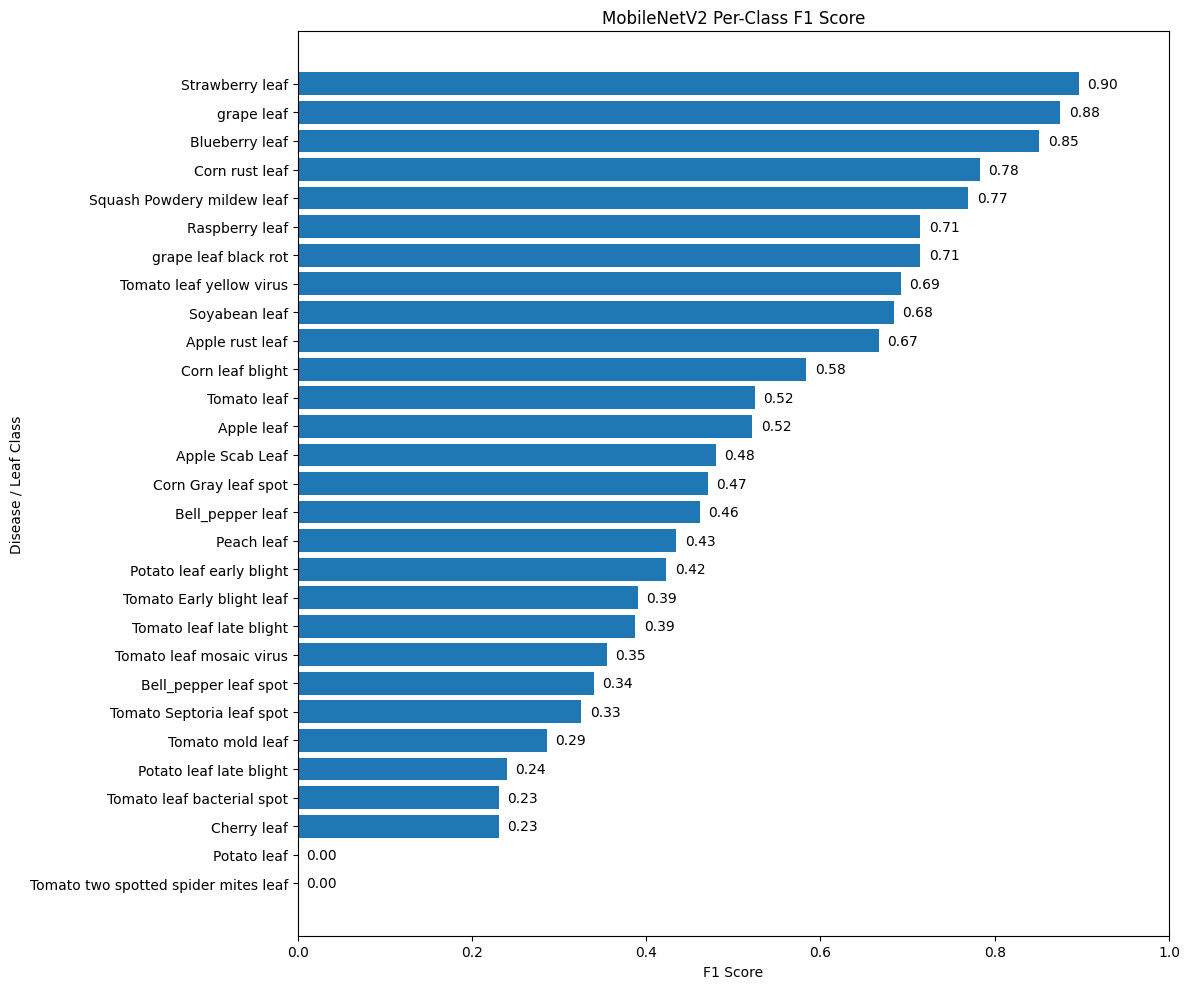

In [ ]:
# ============================================================
# STEP 4 — PER-CLASS F1 SCORE GRAPH
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

plt.barh(
    per_class_df["Class"],
    per_class_df["F1 Score"]
)

plt.xlabel("F1 Score")
plt.ylabel("Disease / Leaf Class")
plt.title("MobileNetV2 Per-Class F1 Score")
plt.xlim(0, 1)

# Display F1 value at the end of each bar
for i, value in enumerate(per_class_df["F1 Score"]):
    plt.text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

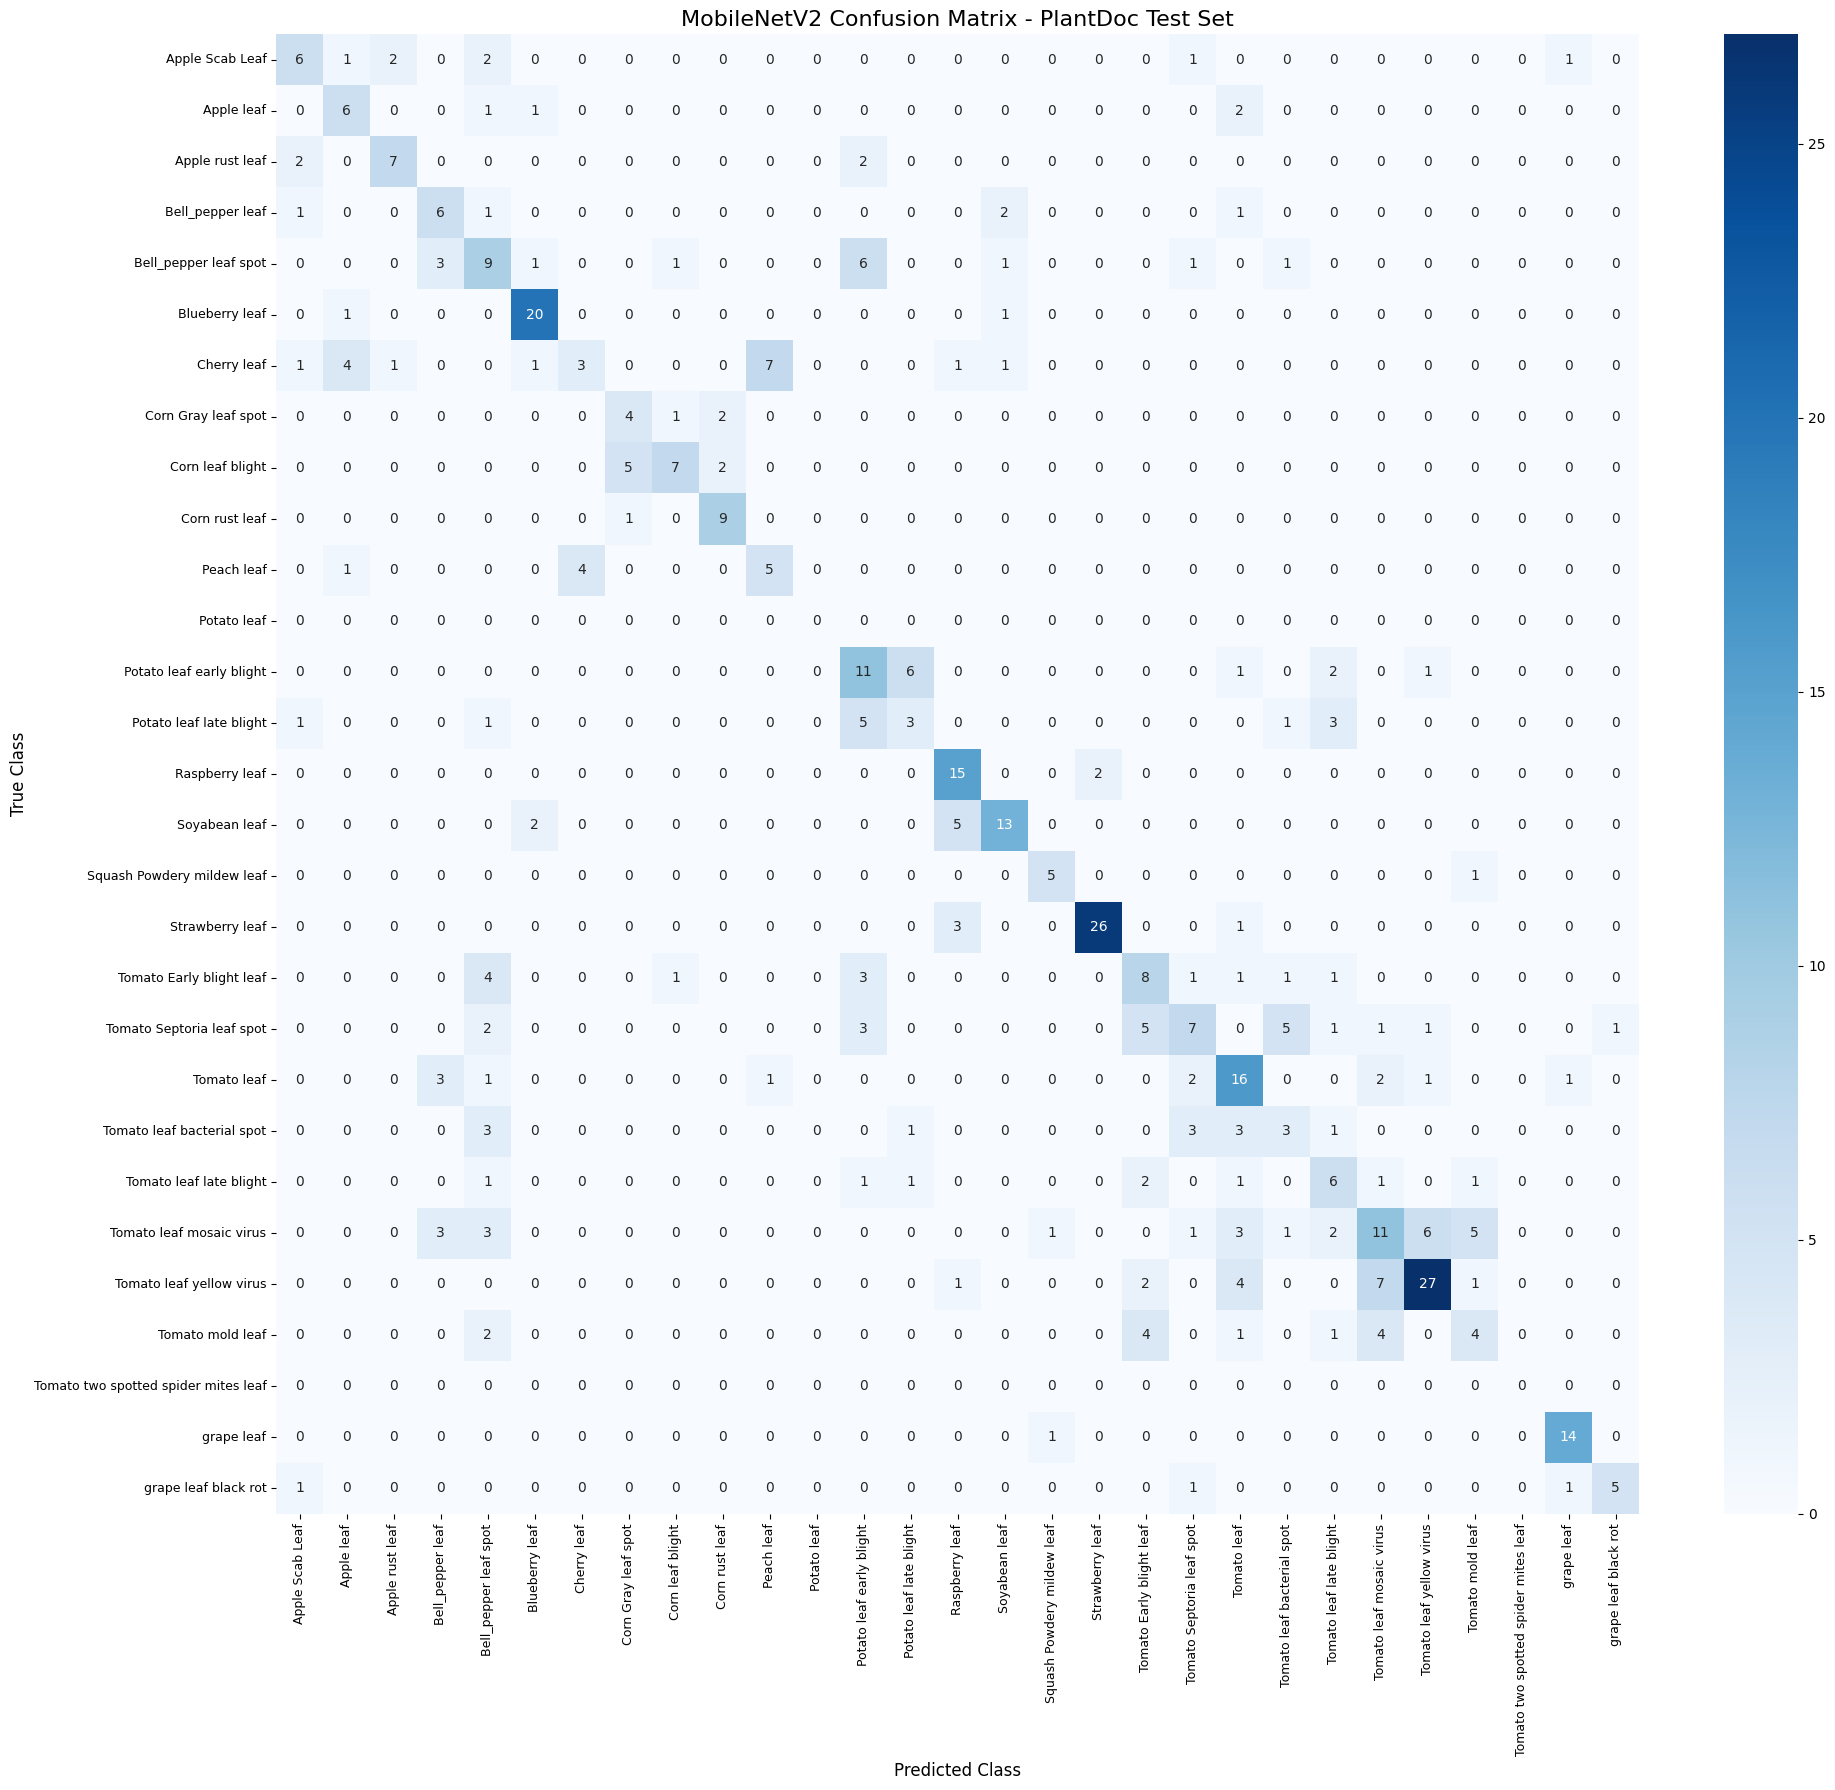

In [ ]:
# ============================================================
# STEP 5 — MOBILENETV2 CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 18))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    cbar=True
)

plt.title(
    "MobileNetV2 Confusion Matrix - PlantDoc Test Set",
    fontsize=16
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)

plt.xticks(
    rotation=90,
    fontsize=9
)

plt.yticks(
    rotation=0,
    fontsize=9
)

plt.tight_layout()

plt.show()

===== TOP 15 MISCLASSIFICATIONS =====


,True Class,Predicted Class,Count
27,Cherry leaf,Peach leaf,7
98,Tomato leaf yellow virus,Tomato leaf mosaic virus,7
17,Bell_pepper leaf spot,Potato leaf early blight,6
93,Tomato leaf mosaic virus,Tomato leaf yellow virus,6
37,Potato leaf early blight,Potato leaf late blight,6
61,Tomato Septoria leaf spot,Tomato Early blight leaf,5
48,Soyabean leaf,Raspberry leaf,5
94,Tomato leaf mosaic virus,Tomato mold leaf,5
62,Tomato Septoria leaf spot,Tomato leaf bacterial spot,5
32,Corn leaf blight,Corn Gray leaf spot,5


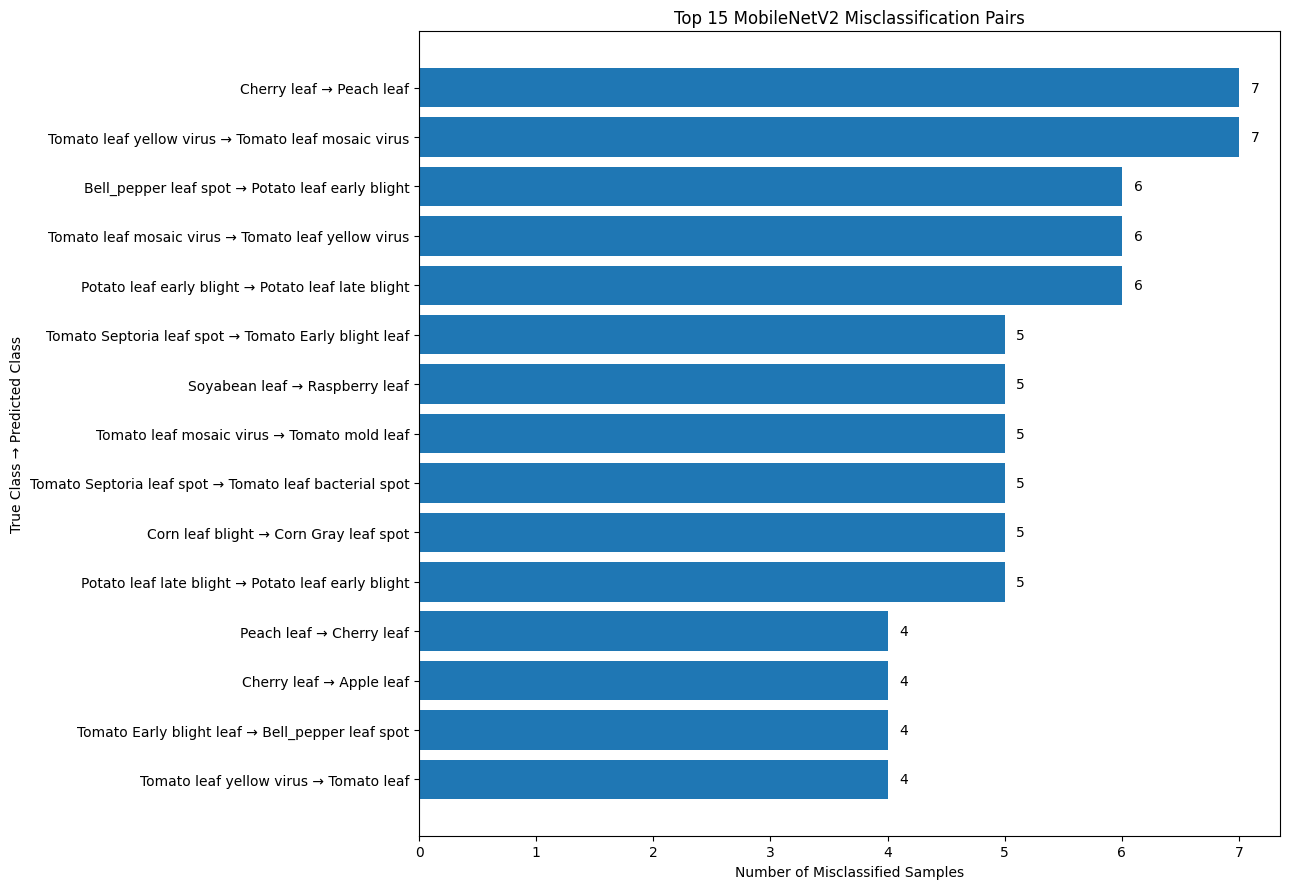

In [ ]:
# ============================================================
# STEP 6 — TOP 15 MISCLASSIFICATION GRAPH
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

confusions = []

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confusions.append({
                "True Class": classes[i],
                "Predicted Class": classes[j],
                "Count": int(cm[i, j])
            })

confusion_df = pd.DataFrame(confusions)

# Get top 15 errors
top15 = confusion_df.sort_values(
    "Count",
    ascending=False
).head(15).copy()

# Create readable labels
top15["Pair"] = (
    top15["True Class"]
    + " → "
    + top15["Predicted Class"]
)

print("===== TOP 15 MISCLASSIFICATIONS =====")
display(top15[["True Class", "Predicted Class", "Count"]])

# Plot
plt.figure(figsize=(13, 9))

plt.barh(
    top15["Pair"][::-1],
    top15["Count"][::-1]
)

plt.xlabel("Number of Misclassified Samples")
plt.ylabel("True Class → Predicted Class")
plt.title("Top 15 MobileNetV2 Misclassification Pairs")

# Add values
for i, value in enumerate(top15["Count"][::-1]):
    plt.text(
        value + 0.1,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()
plt.show()

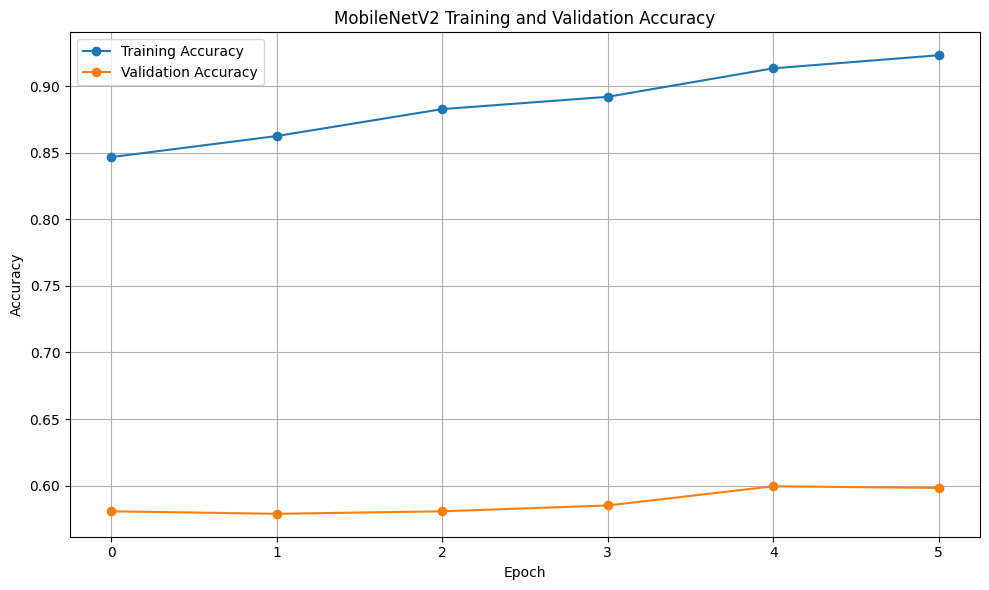

In [ ]:
# ============================================================
# STEP 7 — TRAINING AND VALIDATION ACCURACY
# ============================================================

import matplotlib.pyplot as plt

history_dict = history_improved.history

plt.figure(figsize=(10, 6))

plt.plot(
    history_dict["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_dict["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

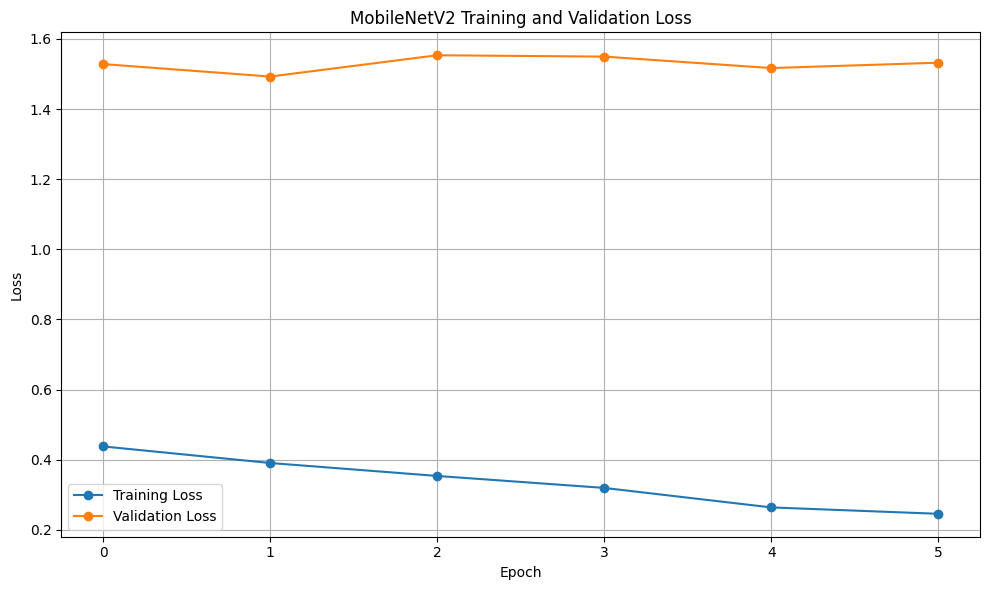

In [ ]:
# ============================================================
# STEP 8 — TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_dict["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_dict["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

===== YOLOv8n FINAL TEST METRICS =====


,Metric,Value
0,Precision,58.7
1,Recall,60.0
2,mAP@50,62.2
3,mAP@50-95,49.0


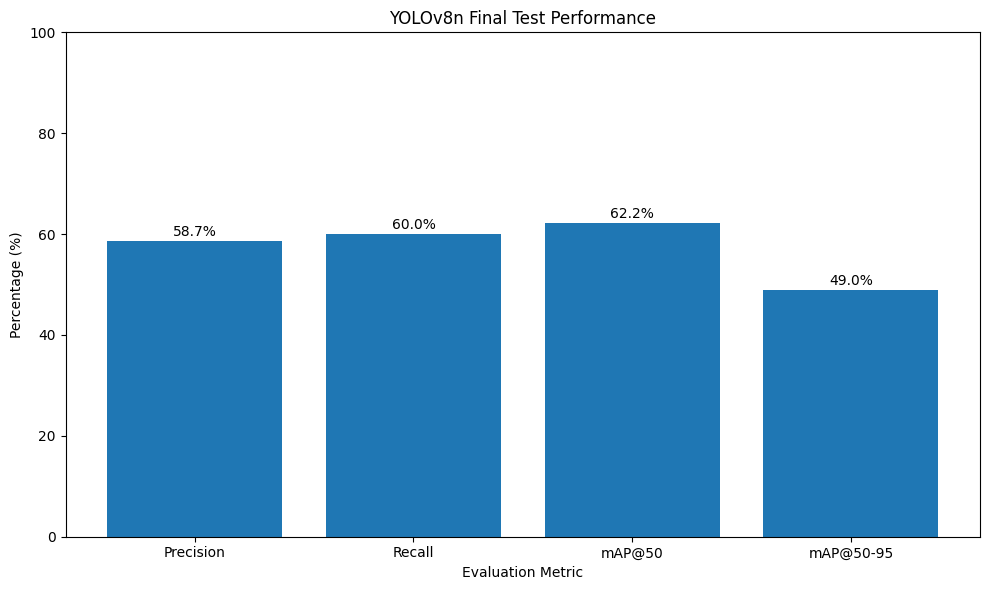

In [ ]:
# ============================================================
# STEP 9 — YOLOv8n FINAL PERFORMANCE GRAPH
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

yolo_metrics = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "mAP@50",
        "mAP@50-95"
    ],
    "Value": [
        58.7,
        60.0,
        62.2,
        49.0
    ]
})

print("===== YOLOv8n FINAL TEST METRICS =====")
display(yolo_metrics)

plt.figure(figsize=(10, 6))

plt.bar(
    yolo_metrics["Metric"],
    yolo_metrics["Value"]
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Percentage (%)")
plt.title("YOLOv8n Final Test Performance")
plt.ylim(0, 100)

for i, value in enumerate(yolo_metrics["Value"]):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 10 — SAVE ALL RESULTS TABLES TO EXCEL
# ============================================================

import pandas as pd

excel_path = "/content/Crop_Disease_Project/Final_Project_Results.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    # Sheet 1: Overall model comparison
    comparison_df.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False
    )

    # Sheet 2: Complete 29-class classification results
    per_class_df.to_excel(
        writer,
        sheet_name="29-Class Results",
        index=False
    )

    # Sheet 3: Top 15 misclassifications
    top15[[
        "True Class",
        "Predicted Class",
        "Count"
    ]].to_excel(
        writer,
        sheet_name="Top 15 Errors",
        index=False
    )

    # Sheet 4: YOLOv8 metrics
    yolo_metrics.to_excel(
        writer,
        sheet_name="YOLOv8 Metrics",
        index=False
    )

print("==============================================")
print("Excel file created successfully!")
print("==============================================")
print(excel_path)

Excel file created successfully!
/content/Crop_Disease_Project/Final_Project_Results.xlsx


In [ ]:
# ============================================================
# STEP 11 — CREATE RESULTS GRAPH FOLDER
# ============================================================

import os

graphs_dir = "/content/Crop_Disease_Project/Results/Graphs"

os.makedirs(graphs_dir, exist_ok=True)

print("Graph folder created successfully:")
print(graphs_dir)

Graph folder created successfully:
/content/Crop_Disease_Project/Results/Graphs


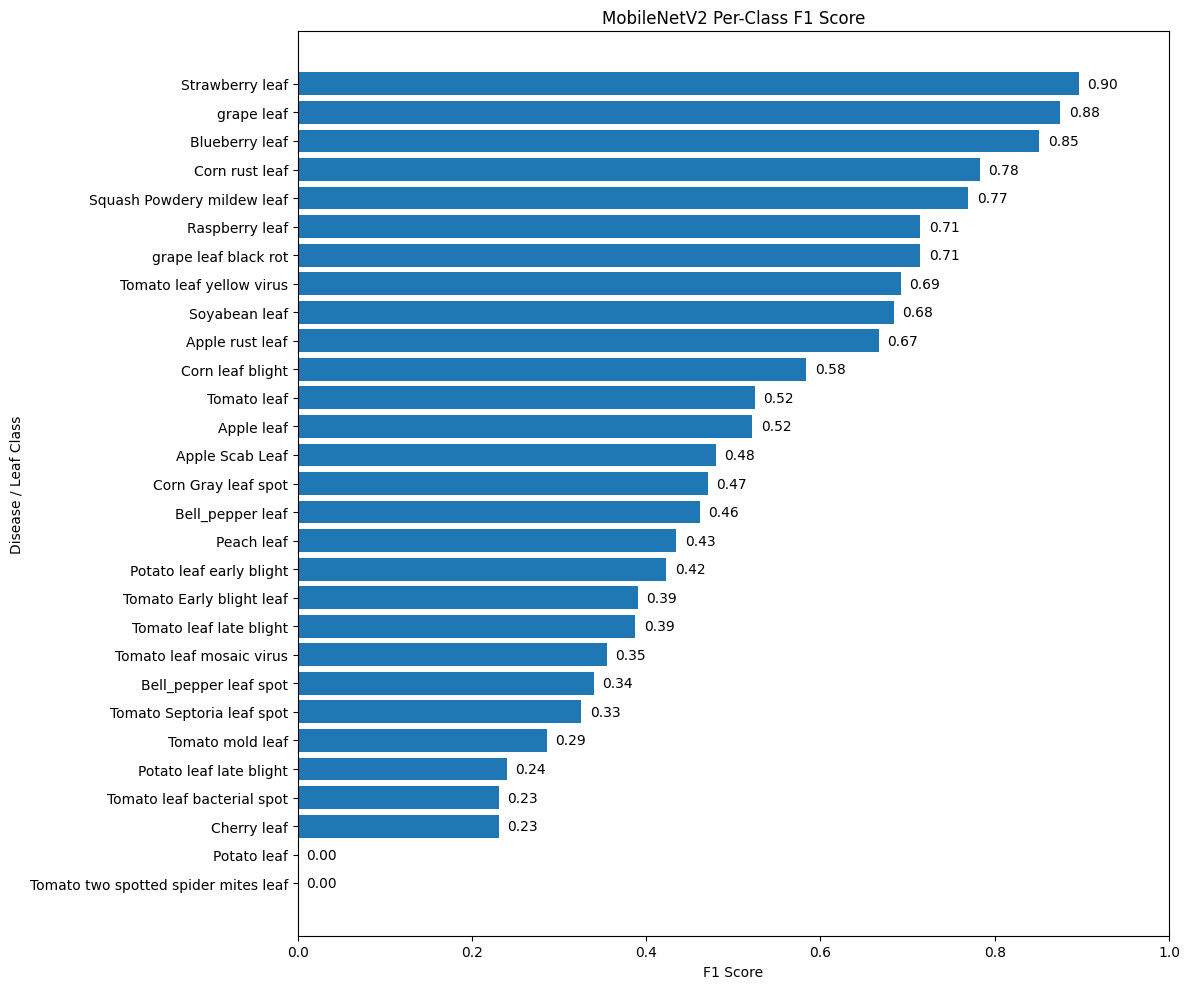

Saved successfully:
/content/Crop_Disease_Project/Results/Graphs/MobileNetV2_Per_Class_F1.png


In [ ]:
# ============================================================
# STEP 12 — SAVE PER-CLASS F1 GRAPH
# ============================================================

import matplotlib.pyplot as plt

f1_graph_path = (
    "/content/Crop_Disease_Project/Results/Graphs/"
    "MobileNetV2_Per_Class_F1.png"
)

plt.figure(figsize=(12, 10))

plt.barh(
    per_class_df["Class"],
    per_class_df["F1 Score"]
)

plt.xlabel("F1 Score")
plt.ylabel("Disease / Leaf Class")
plt.title("MobileNetV2 Per-Class F1 Score")
plt.xlim(0, 1)

for i, value in enumerate(per_class_df["F1 Score"]):
    plt.text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    f1_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved successfully:")
print(f1_graph_path)

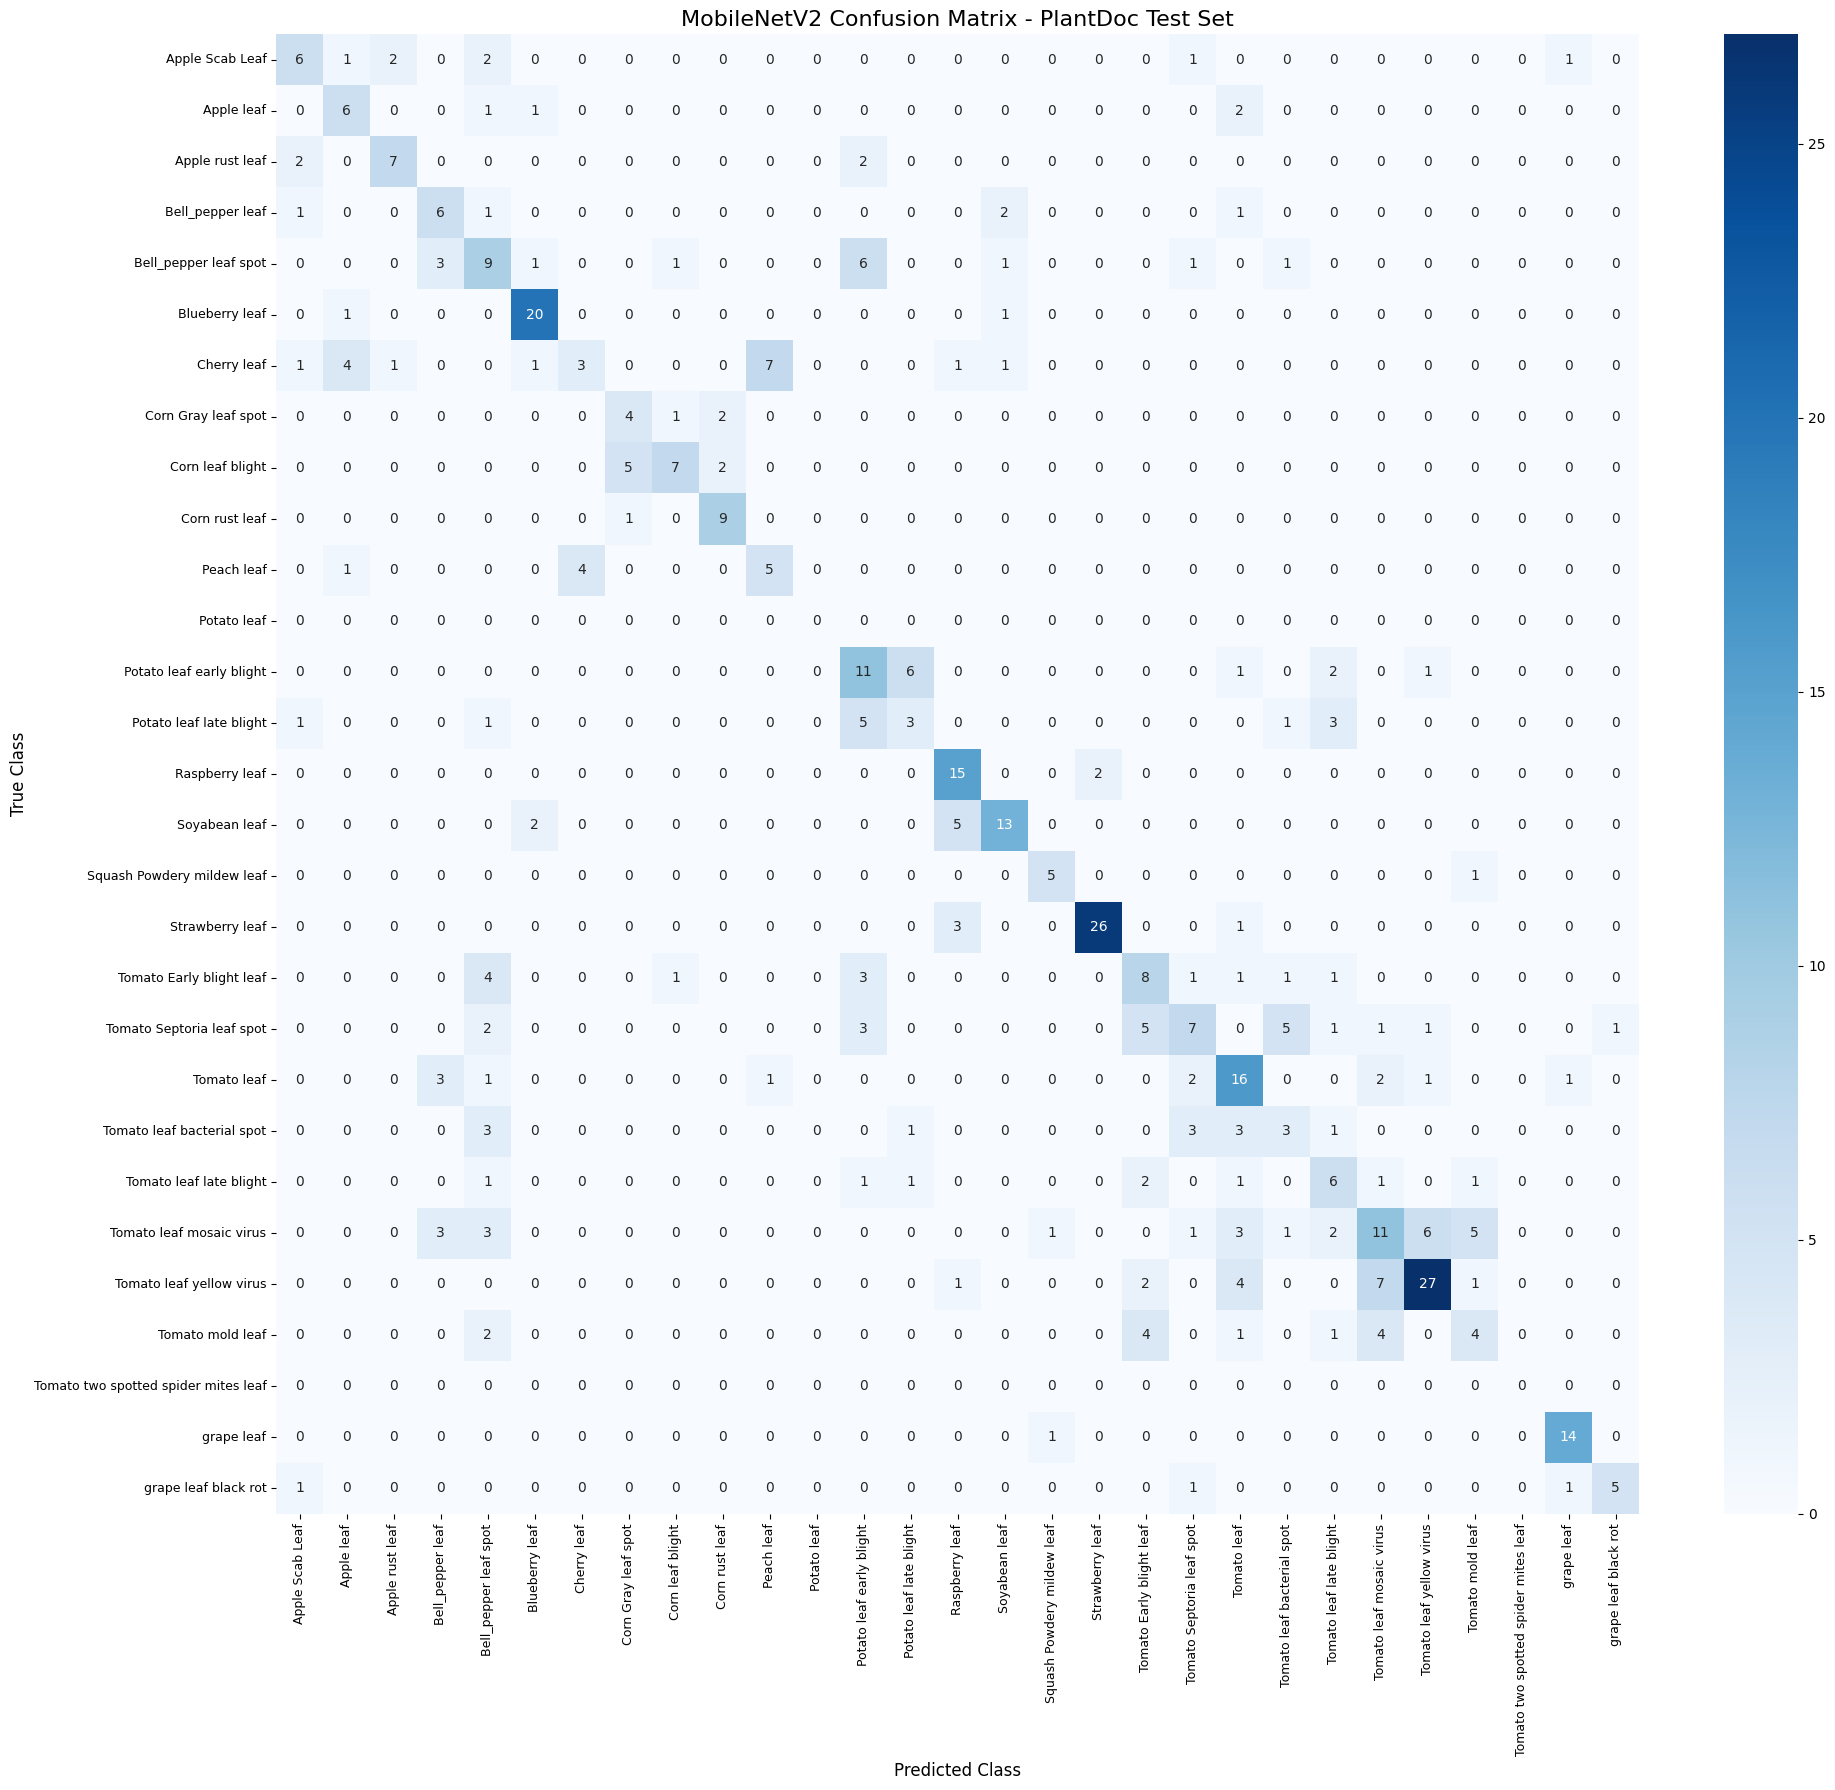

Saved successfully:
/content/Crop_Disease_Project/Results/Graphs/MobileNetV2_Confusion_Matrix.png


In [ ]:
# ============================================================
# STEP 13 — SAVE CONFUSION MATRIX
# ============================================================

cm_graph_path = (
    "/content/Crop_Disease_Project/Results/Graphs/"
    "MobileNetV2_Confusion_Matrix.png"
)

plt.figure(figsize=(20, 18))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    cbar=True
)

plt.title(
    "MobileNetV2 Confusion Matrix - PlantDoc Test Set",
    fontsize=16
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)

plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()

plt.savefig(
    cm_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved successfully:")
print(cm_graph_path)

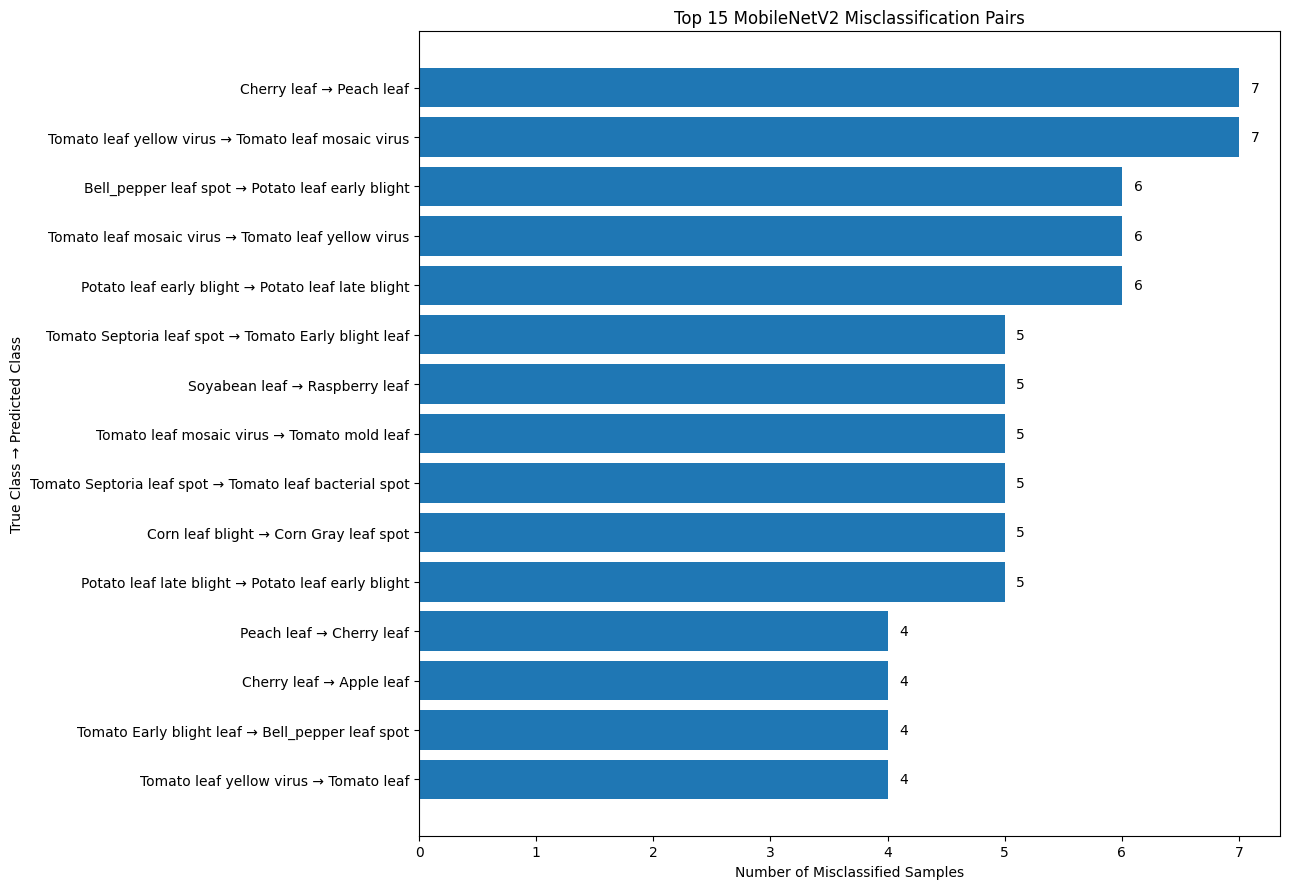

Saved successfully:
/content/Crop_Disease_Project/Results/Graphs/MobileNetV2_Top15_Misclassifications.png


In [ ]:
# ============================================================
# STEP 14 — SAVE TOP 15 MISCLASSIFICATION GRAPH
# ============================================================

top15_graph_path = (
    "/content/Crop_Disease_Project/Results/Graphs/"
    "MobileNetV2_Top15_Misclassifications.png"
)

plt.figure(figsize=(13, 9))

plt.barh(
    top15["Pair"][::-1],
    top15["Count"][::-1]
)

plt.xlabel("Number of Misclassified Samples")
plt.ylabel("True Class → Predicted Class")
plt.title("Top 15 MobileNetV2 Misclassification Pairs")

for i, value in enumerate(top15["Count"][::-1]):
    plt.text(
        value + 0.1,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()

plt.savefig(
    top15_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved successfully:")
print(top15_graph_path)

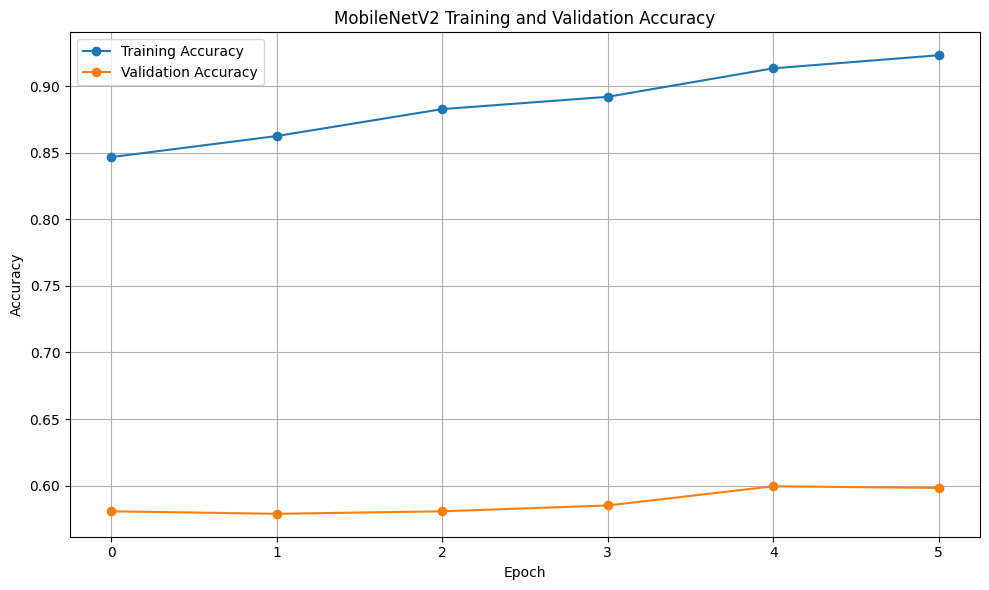

Saved successfully:
/content/Crop_Disease_Project/Results/Graphs/MobileNetV2_Training_Validation_Accuracy.png


In [ ]:
# ============================================================
# STEP 15 — SAVE TRAINING & VALIDATION ACCURACY GRAPH
# ============================================================

accuracy_graph_path = (
    "/content/Crop_Disease_Project/Results/Graphs/"
    "MobileNetV2_Training_Validation_Accuracy.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    history_dict["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_dict["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    accuracy_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved successfully:")
print(accuracy_graph_path)

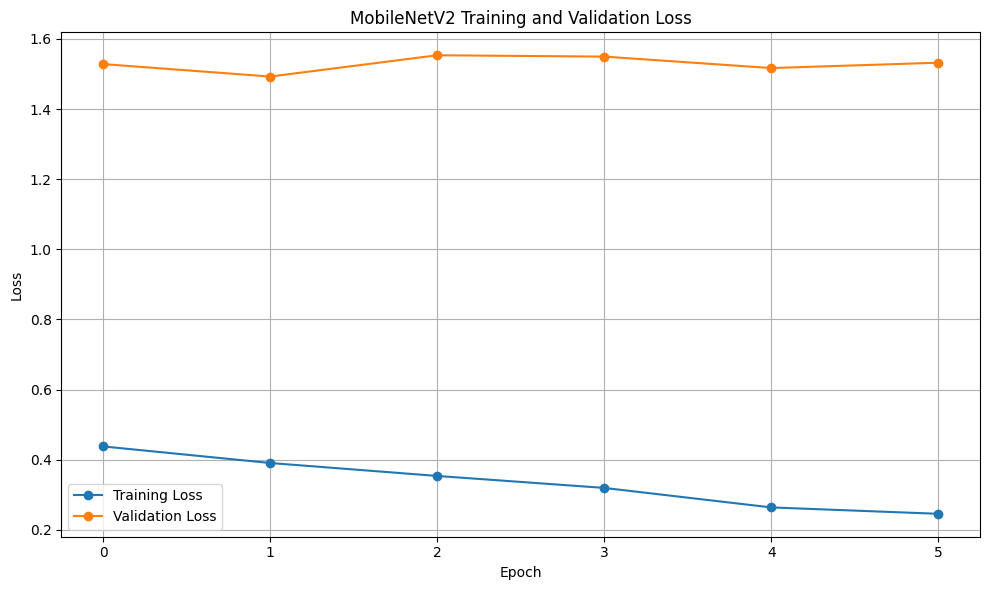

Saved successfully:
/content/Crop_Disease_Project/Results/Graphs/MobileNetV2_Training_Validation_Loss.png


In [ ]:
# ============================================================
# STEP 16 — SAVE TRAINING & VALIDATION LOSS GRAPH
# ============================================================

loss_graph_path = (
    "/content/Crop_Disease_Project/Results/Graphs/"
    "MobileNetV2_Training_Validation_Loss.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    history_dict["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_dict["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    loss_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved successfully:")
print(loss_graph_path)

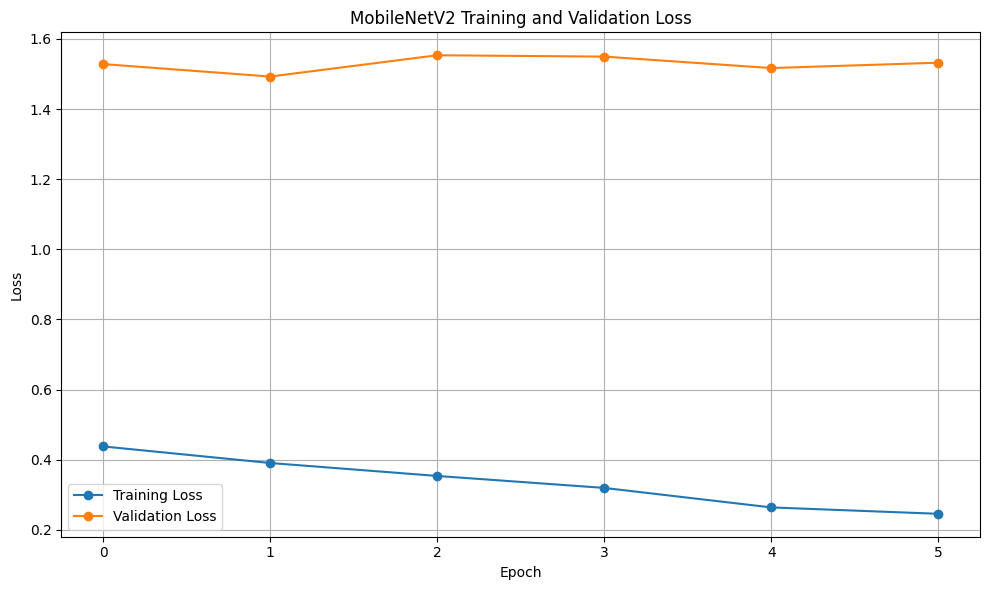

Saved successfully:
/content/Crop_Disease_Project/Results/Graphs/MobileNetV2_Training_Validation_Loss.png


In [ ]:
# ============================================================
# STEP 16 — SAVE TRAINING & VALIDATION LOSS GRAPH
# ============================================================

loss_graph_path = (
    "/content/Crop_Disease_Project/Results/Graphs/"
    "MobileNetV2_Training_Validation_Loss.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    history_dict["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_dict["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    loss_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved successfully:")
print(loss_graph_path)

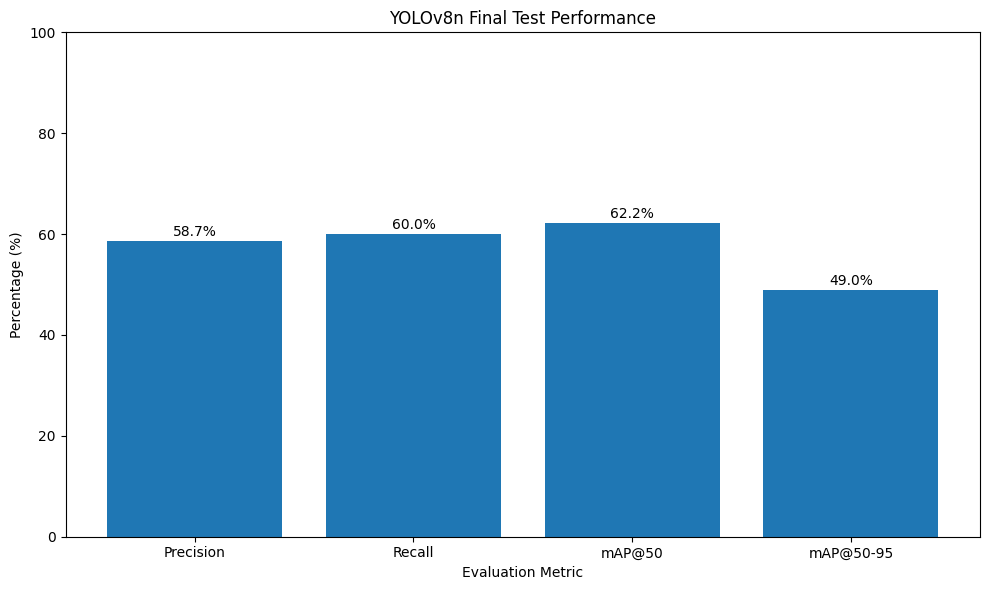

Saved successfully:
/content/Crop_Disease_Project/Results/Graphs/YOLOv8n_Final_Test_Performance.png


In [ ]:
# ============================================================
# STEP 17 — SAVE YOLOv8n FINAL PERFORMANCE GRAPH
# ============================================================

yolo_graph_path = (
    "/content/Crop_Disease_Project/Results/Graphs/"
    "YOLOv8n_Final_Test_Performance.png"
)

plt.figure(figsize=(10, 6))

plt.bar(
    yolo_metrics["Metric"],
    yolo_metrics["Value"]
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Percentage (%)")
plt.title("YOLOv8n Final Test Performance")
plt.ylim(0, 100)

for i, value in enumerate(yolo_metrics["Value"]):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    yolo_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved successfully:")
print(yolo_graph_path)

In [ ]:
# ============================================================
# STEP 18 — ORGANIZE FINAL PROJECT RESULTS
# ============================================================

import os
import shutil

results_dir = "/content/Crop_Disease_Project/Results"
graphs_dir = os.path.join(results_dir, "Graphs")

# Copy Excel results into Results folder
source_excel = "/content/Crop_Disease_Project/Final_Project_Results.xlsx"
destination_excel = os.path.join(
    results_dir,
    "Final_Project_Results.xlsx"
)

if os.path.exists(source_excel):
    shutil.copy2(source_excel, destination_excel)

print("=" * 65)
print("       FINAL PROJECT RESULTS ORGANIZED")
print("=" * 65)

print("\nResults folder:")
print(results_dir)

print("\nGraphs:")
for file in sorted(os.listdir(graphs_dir)):
    print("✓", file)

print("\nExcel:")
print("✓ Final_Project_Results.xlsx")

print("\n" + "=" * 65)
print("ALL RESULTS ARE READY FOR YOUR PROJECT REPORT")
print("=" * 65)

       FINAL PROJECT RESULTS ORGANIZED

Results folder:
/content/Crop_Disease_Project/Results

Graphs:
✓ MobileNetV2_Confusion_Matrix.png
✓ MobileNetV2_Per_Class_F1.png
✓ MobileNetV2_Top15_Misclassifications.png
✓ MobileNetV2_Training_Validation_Accuracy.png
✓ MobileNetV2_Training_Validation_Loss.png
✓ YOLOv8n_Final_Test_Performance.png

Excel:
✓ Final_Project_Results.xlsx

ALL RESULTS ARE READY FOR YOUR PROJECT REPORT
